# CNN comparison analysis

Short analysis notebook for saved CNN outputs.

In [ ]:
# Optional: mount Google Drive when running in Colab
try:
    from google.colab import drive  # type: ignore
    drive.mount('/content/drive')
    IN_COLAB = True
except Exception:
    IN_COLAB = False

print(f"IN_COLAB = {IN_COLAB}")

Mounted at /content/drive
IN_COLAB = True


In [ ]:
# Imports

import os
import json
import math
import glob
import warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

from IPython.display import display, Markdown
from sklearn.metrics import ConfusionMatrixDisplay
from scipy import stats
from scipy.optimize import curve_fit

warnings.filterwarnings("ignore", category=RuntimeWarning)

plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

## 1. Configure paths

In [ ]:
# Path configuration

DRIVE_ROOT = Path("/content/drive/MyDrive/MSC_Research/CNNs")  # <-- change only if needed

CONFIG_PATH = DRIVE_ROOT / "Configs" / "CNN_Config.csv"
RESULTS_ROOT = DRIVE_ROOT / "Results"
RUN_ARTIFACTS_DIR = RESULTS_ROOT / "Run_JSON"
MODELS_DIR = DRIVE_ROOT / "Models"
GRADCAM_DIR = DRIVE_ROOT / "Grad Cam"

ANALYSIS_ROOT = DRIVE_ROOT / "Analysis_CNN_Comparison"
FIG_DIR = ANALYSIS_ROOT / "figures"
TABLE_DIR = ANALYSIS_ROOT / "tables"

for p in [ANALYSIS_ROOT, FIG_DIR, TABLE_DIR]:
    p.mkdir(parents=True, exist_ok=True)

for name, p in {
    "CONFIG_PATH": CONFIG_PATH,
    "RUN_ARTIFACTS_DIR": RUN_ARTIFACTS_DIR,
    "MODELS_DIR": MODELS_DIR,
    "GRADCAM_DIR": GRADCAM_DIR,
    "ANALYSIS_ROOT": ANALYSIS_ROOT,
}.items():
    print(f"{name}: {p}")

CONFIG_PATH: /content/drive/MyDrive/MSC_Research/CNNs/Configs/CNN_Config.csv
RUN_ARTIFACTS_DIR: /content/drive/MyDrive/MSC_Research/CNNs/Results/Run_JSON
MODELS_DIR: /content/drive/MyDrive/MSC_Research/CNNs/Models
GRADCAM_DIR: /content/drive/MyDrive/MSC_Research/CNNs/Grad Cam
ANALYSIS_ROOT: /content/drive/MyDrive/MSC_Research/CNNs/Analysis_CNN_Comparison


In [ ]:
# Quick path checks

json_files = sorted(RUN_ARTIFACTS_DIR.glob("*_results.json"))
csv_files = sorted(MODELS_DIR.glob("*.csv"))
gradcam_runs = sorted([p for p in GRADCAM_DIR.glob("*") if p.is_dir()])

print(f"JSON bundles found : {len(json_files)}")
print(f"Model CSVs found   : {len(csv_files)}")
print(f"Grad-CAM run dirs  : {len(gradcam_runs)}")

if len(json_files) == 0:
    raise FileNotFoundError(
        "No saved run JSON bundles were found. "
        "Check DRIVE_ROOT / RUN_ARTIFACTS_DIR and confirm the training notebook saved artifacts there."
    )

JSON bundles found : 36
Model CSVs found   : 36
Grad-CAM run dirs  : 36


## 2. Load saved run bundles

In [ ]:
def safe_read_json(path):
    with open(path, "r") as f:
        return json.load(f)

def to_dataframe(records, extra=None):
    if records is None:
        return pd.DataFrame()
    if isinstance(records, dict):
        records = [records]
    df = pd.DataFrame(records)
    if extra:
        for k, v in extra.items():
            df[k] = v
    return df

bundles = []
for fp in json_files:
    try:
        bundle = safe_read_json(fp)
        bundle["_source_json"] = str(fp)
        bundles.append(bundle)
    except Exception as e:
        print(f"Failed to read {fp.name}: {e}")

print(f"Loaded {len(bundles)} bundles.")

Loaded 36 bundles.


In [ ]:
# Flatten key tables from each bundle

final_frames = []
history_frames = []
per_class_frames = []
pred_frames = []
split_frames = []
gradcam_meta_frames = []
confusion_store = {}

for b in bundles:
    run_id = b.get("run_id")
    dataset = b.get("dataset")
    model = b.get("model")
    metadata = b.get("metadata", {})

    # Final summary
    fdf = to_dataframe(b.get("final_summary", []))
    if len(fdf) == 0 and metadata:
        fdf = pd.DataFrame([metadata])
    if len(fdf):
        fdf["_source_json"] = b.get("_source_json")
        final_frames.append(fdf)

    # History
    hdf = to_dataframe(b.get("history", []), {"_source_json": b.get("_source_json")})
    if len(hdf):
        history_frames.append(hdf)

    # Per-class metrics
    pcdf = to_dataframe(
        b.get("metrics", {}).get("per_class_test", []),
        {"run_id": run_id, "dataset": dataset, "model": model, "_source_json": b.get("_source_json")}
    )
    if len(pcdf):
        per_class_frames.append(pcdf)

    # Predictions
    for split_name, rows in b.get("predictions", {}).items():
        pdf = to_dataframe(
            rows,
            {"run_id": run_id, "dataset": dataset, "model": model, "pred_split": split_name, "_source_json": b.get("_source_json")}
        )
        if len(pdf):
            pred_frames.append(pdf)

    # Splits
    for split_name, rows in b.get("splits", {}).items():
        sdf = to_dataframe(
            rows,
            {"run_id": run_id, "dataset": dataset, "model": model, "saved_split_name": split_name, "_source_json": b.get("_source_json")}
        )
        if len(sdf):
            split_frames.append(sdf)

    # Confusion matrices
    cm = b.get("metrics", {}).get("confusion_matrix_test", None)
    if cm is not None:
        confusion_store[run_id] = np.array(cm)

    # Grad-CAM metadata
    gdir = Path(b.get("manifest", {}).get("gradcam_dir", "")) if b.get("manifest") else Path("")
    meta_csv = gdir / "gradcam_metadata.csv"
    if meta_csv.exists():
        gdf = pd.read_csv(meta_csv)
        gdf["run_id"] = run_id
        gdf["dataset"] = dataset
        gdf["model"] = model
        gdf["gradcam_dir"] = str(gdir)
        gradcam_meta_frames.append(gdf)

final_df = pd.concat(final_frames, ignore_index=True) if final_frames else pd.DataFrame()
history_df = pd.concat(history_frames, ignore_index=True) if history_frames else pd.DataFrame()
per_class_df = pd.concat(per_class_frames, ignore_index=True) if per_class_frames else pd.DataFrame()
pred_df = pd.concat(pred_frames, ignore_index=True) if pred_frames else pd.DataFrame()
split_df = pd.concat(split_frames, ignore_index=True) if split_frames else pd.DataFrame()
gradcam_df = pd.concat(gradcam_meta_frames, ignore_index=True) if gradcam_meta_frames else pd.DataFrame()

print("Shapes")
print(" final_df   :", final_df.shape)
print(" history_df :", history_df.shape)
print(" per_class_df:", per_class_df.shape)
print(" pred_df    :", pred_df.shape)
print(" split_df   :", split_df.shape)
print(" gradcam_df :", gradcam_df.shape)

Shapes
 final_df   : (36, 39)
 history_df : (607, 24)
 per_class_df: (234, 9)
 pred_df    : (169086, 24)
 split_df   : (388500, 27)
 gradcam_df : (864, 17)


In [ ]:
# Standardise types and inspect columns

def numeric_if_present(df, cols):
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

final_df = numeric_if_present(final_df, [
    "seed","data_fraction_requested","data_fraction_used","best_epoch","epochs_trained","stopped_early",
    "final_val_loss","final_val_acc","final_val_balanced_acc","final_val_f1_macro","final_val_f1_weighted","final_val_auroc_ovr",
    "test_loss","test_acc","test_balanced_acc","test_f1_macro","test_f1_weighted","test_auroc_ovr",
    "total_params","trainable_params","run_seconds","dropout_p","batch_size","img_size","best_val_loss"
])

history_df = numeric_if_present(history_df, [
    "epoch","seed","data_fraction_requested","data_fraction_used","train_loss","train_acc","train_f1_macro","train_n_seen","train_seconds",
    "val_loss","val_acc","val_balanced_acc","val_f1_macro","val_f1_weighted","val_auroc_ovr","val_n_seen",
    "lr","best_val_loss_so_far","best_epoch_so_far","patience_counter"
])

per_class_df = numeric_if_present(per_class_df, ["precision","recall","f1-score","support","seed","data_fraction_requested","data_fraction_used"])
pred_df = numeric_if_present(pred_df, ["true_label","pred_label","correct","confidence","seed","data_fraction_requested","data_fraction_used"])
gradcam_df = numeric_if_present(gradcam_df, ["index","true_label","pred_label","correct","confidence","seed","data_fraction_requested","data_fraction_used"])

display(final_df.head())
print("\nColumns in final_df:")
print(sorted(final_df.columns.tolist()))

# Backfill key run-level columns into child tables when they are missing
run_level_cols = ["run_id", "dataset", "model", "seed", "data_fraction_requested", "data_fraction_used"]
run_level_lookup = pd.DataFrame()
if len(final_df) and "run_id" in final_df.columns:
    available = [c for c in run_level_cols if c in final_df.columns]
    run_level_lookup = final_df[available].drop_duplicates(subset=["run_id"]).copy()


def attach_run_level_columns(df):
    if len(df) == 0 or len(run_level_lookup) == 0 or "run_id" not in df.columns:
        return df
    missing = [c for c in run_level_lookup.columns if c != "run_id" and c not in df.columns]
    if not missing:
        return df
    return df.merge(run_level_lookup[["run_id", *missing]], on="run_id", how="left")

per_class_df = attach_run_level_columns(per_class_df)
pred_df = attach_run_level_columns(pred_df)
gradcam_df = attach_run_level_columns(gradcam_df)
split_df = attach_run_level_columns(split_df)

per_class_df = numeric_if_present(per_class_df, ["precision","recall","f1-score","f1_score","support","seed","data_fraction_requested","data_fraction_used","class_id"])
pred_df = numeric_if_present(pred_df, ["true_label","pred_label","correct","confidence","seed","data_fraction_requested","data_fraction_used"])
gradcam_df = numeric_if_present(gradcam_df, ["index","true_label","pred_label","correct","confidence","seed","data_fraction_requested","data_fraction_used"])


,run_id,dataset,model,seed,data_fraction_requested,data_fraction_used,num_classes,best_epoch,epochs_trained,stopped_early,...,dropout_p,label_smoothing,weight_decay,base_lr,use_amp,use_weighted_cross_entropy,do_border_crop,do_clahe,smoke_test,_source_json
0,ISIC2019_efficientnet_b0_100_42,ISIC2019,efficientnet_b0,42,1.00,1.00,8,18,23,1,...,0.2,0.05,0.0001,0.0001,1,1,1,1,0,/content/drive/MyDrive/MSC_Research/CNNs/Resul...
1,ISIC2019_efficientnet_b0_100_43,ISIC2019,efficientnet_b0,43,1.00,1.00,8,23,25,0,...,0.2,0.05,0.0001,0.0001,1,1,1,1,0,/content/drive/MyDrive/MSC_Research/CNNs/Resul...
2,ISIC2019_efficientnet_b0_100_44,ISIC2019,efficientnet_b0,44,1.00,1.00,8,25,25,0,...,0.2,0.05,0.0001,0.0001,1,1,1,1,0,/content/drive/MyDrive/MSC_Research/CNNs/Resul...
3,ISIC2019_efficientnet_b0_25_42,ISIC2019,efficientnet_b0,42,0.25,0.25,8,12,17,1,...,0.2,0.05,0.0001,0.0001,1,1,1,1,0,/content/drive/MyDrive/MSC_Research/CNNs/Resul...
4,ISIC2019_efficientnet_b0_25_43,ISIC2019,efficientnet_b0,43,0.25,0.25,8,13,18,1,...,0.2,0.05,0.0001,0.0001,1,1,1,1,0,/content/drive/MyDrive/MSC_Research/CNNs/Resul...



Columns in final_df:
['_source_json', 'base_lr', 'batch_size', 'best_epoch', 'best_val_loss', 'data_fraction_requested', 'data_fraction_used', 'dataset', 'device', 'do_border_crop', 'do_clahe', 'dropout_p', 'epochs_trained', 'final_val_acc', 'final_val_auroc_ovr', 'final_val_balanced_acc', 'final_val_f1_macro', 'final_val_f1_weighted', 'final_val_loss', 'img_size', 'label_smoothing', 'model', 'num_classes', 'run_id', 'run_seconds', 'seed', 'smoke_test', 'stopped_early', 'test_acc', 'test_auroc_ovr', 'test_balanced_acc', 'test_f1_macro', 'test_f1_weighted', 'test_loss', 'total_params', 'trainable_params', 'use_amp', 'use_weighted_cross_entropy', 'weight_decay']


## 3. Coverage checks

In [ ]:
def show_unique(df, col):
    return sorted(df[col].dropna().astype(str).unique().tolist()) if col in df.columns else []

print("Datasets :", show_unique(final_df, "dataset"))
print("Models   :", show_unique(final_df, "model"))
print("Fractions:", sorted(final_df["data_fraction_used"].dropna().unique().tolist()) if "data_fraction_used" in final_df.columns else [])
print("Seeds    :", sorted(final_df["seed"].dropna().unique().tolist()) if "seed" in final_df.columns else [])

Datasets : ['ISIC2019', 'Messidor2']
Models   : ['efficientnet_b0', 'resnet18']
Fractions: [0.25, 0.5, 1.0]
Seeds    : [42, 43, 44]


In [ ]:
coverage = (
    final_df.groupby(["dataset","model","data_fraction_used"])
    .agg(
        n_runs=("run_id","nunique"),
        seeds=("seed", lambda s: sorted(pd.Series(s).dropna().astype(int).tolist()))
    )
    .reset_index()
    .sort_values(["dataset","model","data_fraction_used"])
)
display(coverage)
coverage.to_csv(TABLE_DIR / "coverage_table.csv", index=False)

,dataset,model,data_fraction_used,n_runs,seeds
0,ISIC2019,efficientnet_b0,0.25,3,"[42, 43, 44]"
1,ISIC2019,efficientnet_b0,0.50,3,"[42, 43, 44]"
2,ISIC2019,efficientnet_b0,1.00,3,"[42, 43, 44]"
3,ISIC2019,resnet18,0.25,3,"[42, 43, 44]"
4,ISIC2019,resnet18,0.50,3,"[42, 43, 44]"
5,ISIC2019,resnet18,1.00,3,"[42, 43, 44]"
6,Messidor2,efficientnet_b0,0.25,3,"[42, 43, 44]"
7,Messidor2,efficientnet_b0,0.50,3,"[42, 43, 44]"
8,Messidor2,efficientnet_b0,1.00,3,"[42, 43, 44]"
9,Messidor2,resnet18,0.25,3,"[42, 43, 44]"


## 4. Helper functions for summaries and plots

In [ ]:
PRIMARY_METRIC = "test_f1_macro"
SECONDARY_METRICS = ["test_acc", "test_balanced_acc", "test_auroc_ovr", "test_loss"]

MODEL_ORDER = sorted(show_unique(final_df, "model"))
DATASET_ORDER = sorted(show_unique(final_df, "dataset"))
FRACTION_ORDER = sorted(final_df["data_fraction_used"].dropna().unique().tolist())

def mean_std_summary(df, group_cols, metrics):
    agg = {}
    for m in metrics:
        agg[m] = ["mean", "std", "min", "max", "count"]
    out = df.groupby(group_cols).agg(agg)
    out.columns = ["_".join(col).strip() for col in out.columns]
    return out.reset_index()

def ci95(series):
    x = pd.Series(series).dropna().astype(float)
    if len(x) <= 1:
        return np.nan
    return stats.t.ppf(0.975, df=len(x)-1) * x.std(ddof=1) / np.sqrt(len(x))

def save_current_fig(name):
    png = FIG_DIR / f"{name}.png"
    pdf = FIG_DIR / f"{name}.pdf"
    plt.savefig(png, bbox_inches="tight")
    plt.savefig(pdf, bbox_inches="tight")
    print(f"Saved: {png.name}, {pdf.name}")

def pretty_metric_name(metric):
    mapping = {
        "test_f1_macro": "Test Macro F1",
        "test_acc": "Test Accuracy",
        "test_balanced_acc": "Test Balanced Accuracy",
        "test_auroc_ovr": "Test AUROC (OvR)",
        "test_loss": "Test Loss",
        "final_val_f1_macro": "Validation Macro F1",
        "val_loss": "Validation Loss",
        "train_loss": "Training Loss",
    }
    return mapping.get(metric, metric)

def format_mean_std(mean, std, digits=4):
    if pd.isna(mean):
        return ""
    if pd.isna(std):
        return f"{mean:.{digits}f}"
    return f"{mean:.{digits}f} ± {std:.{digits}f}"

## 5. Main performance tables

In [ ]:
summary_main = mean_std_summary(
    final_df,
    ["dataset", "model", "data_fraction_used"],
    [PRIMARY_METRIC] + SECONDARY_METRICS
).sort_values(["dataset","model","data_fraction_used"])

display(summary_main)
summary_main.to_csv(TABLE_DIR / "main_performance_summary.csv", index=False)

,dataset,model,data_fraction_used,test_f1_macro_mean,test_f1_macro_std,test_f1_macro_min,test_f1_macro_max,test_f1_macro_count,test_acc_mean,test_acc_std,...,test_auroc_ovr_mean,test_auroc_ovr_std,test_auroc_ovr_min,test_auroc_ovr_max,test_auroc_ovr_count,test_loss_mean,test_loss_std,test_loss_min,test_loss_max,test_loss_count
0,ISIC2019,efficientnet_b0,0.25,0.485556,0.011760,0.475252,0.498367,3,0.636677,0.004671,...,0.835041,0.011509,0.827877,0.848316,3,1.383736,0.029325,1.349884,1.401347,3
1,ISIC2019,efficientnet_b0,0.50,0.516733,0.013767,0.501065,0.526895,3,0.654014,0.006912,...,0.850129,0.009126,0.840414,0.858521,3,1.303815,0.011527,1.295880,1.317037,3
2,ISIC2019,efficientnet_b0,1.00,0.552777,0.008904,0.542586,0.559051,3,0.688796,0.001146,...,0.824750,0.003990,0.820781,0.828760,3,1.388499,0.008778,1.379616,1.397168,3
3,ISIC2019,resnet18,0.25,0.458677,0.007658,0.454115,0.467519,3,0.603080,0.004935,...,0.845119,0.018648,0.824826,0.861502,3,1.332543,0.001361,1.330975,1.333418,3
4,ISIC2019,resnet18,0.50,0.512207,0.005095,0.509059,0.518085,3,0.655091,0.008782,...,0.841135,0.009716,0.831829,0.851215,3,1.353721,0.037801,1.314871,1.390378,3
5,ISIC2019,resnet18,1.00,0.549405,0.011501,0.538847,0.561661,3,0.670059,0.004471,...,0.848505,0.006924,0.844471,0.856500,3,1.305473,0.083952,1.211669,1.373556,3
6,Messidor2,efficientnet_b0,0.25,0.413503,0.028580,0.380862,0.434032,3,0.440252,0.078553,...,0.742322,0.058360,0.696736,0.808095,3,1.362918,0.142226,1.206176,1.483739,3
7,Messidor2,efficientnet_b0,0.50,0.379060,0.073748,0.294693,0.431262,3,0.493711,0.115285,...,0.700439,0.025808,0.680433,0.729570,3,1.244555,0.099090,1.148787,1.346663,3
8,Messidor2,efficientnet_b0,1.00,0.450266,0.042378,0.424708,0.499183,3,0.544025,0.043828,...,0.761858,0.049481,0.707753,0.804813,3,1.138323,0.013458,1.124683,1.151592,3
9,Messidor2,resnet18,0.25,0.293345,0.127016,0.218489,0.440000,3,0.484277,0.113730,...,0.659034,0.112182,0.585933,0.788197,3,1.293700,0.100037,1.220186,1.407620,3


In [ ]:
# Compact dissertation-ready table

compact_rows = []
for _, row in summary_main.iterrows():
    compact_rows.append({
        "dataset": row["dataset"],
        "model": row["model"],
        "data_fraction_used": row["data_fraction_used"],
        "test_macro_f1": format_mean_std(row.get("test_f1_macro_mean"), row.get("test_f1_macro_std")),
        "test_accuracy": format_mean_std(row.get("test_acc_mean"), row.get("test_acc_std")),
        "test_balanced_accuracy": format_mean_std(row.get("test_balanced_acc_mean"), row.get("test_balanced_acc_std")),
        "test_auroc_ovr": format_mean_std(row.get("test_auroc_ovr_mean"), row.get("test_auroc_ovr_std")),
        "test_loss": format_mean_std(row.get("test_loss_mean"), row.get("test_loss_std")),
        "n_runs": int(row.get("test_f1_macro_count", np.nan)) if not pd.isna(row.get("test_f1_macro_count", np.nan)) else np.nan,
    })

compact_main = pd.DataFrame(compact_rows)
display(compact_main)
compact_main.to_csv(TABLE_DIR / "main_performance_compact.csv", index=False)

,dataset,model,data_fraction_used,test_macro_f1,test_accuracy,test_balanced_accuracy,test_auroc_ovr,test_loss,n_runs
0,ISIC2019,efficientnet_b0,0.25,0.4856 ± 0.0118,0.6367 ± 0.0047,0.5262 ± 0.0108,0.8350 ± 0.0115,1.3837 ± 0.0293,3
1,ISIC2019,efficientnet_b0,0.50,0.5167 ± 0.0138,0.6540 ± 0.0069,0.5557 ± 0.0137,0.8501 ± 0.0091,1.3038 ± 0.0115,3
2,ISIC2019,efficientnet_b0,1.00,0.5528 ± 0.0089,0.6888 ± 0.0011,0.5656 ± 0.0101,0.8247 ± 0.0040,1.3885 ± 0.0088,3
3,ISIC2019,resnet18,0.25,0.4587 ± 0.0077,0.6031 ± 0.0049,0.5143 ± 0.0175,0.8451 ± 0.0186,1.3325 ± 0.0014,3
4,ISIC2019,resnet18,0.50,0.5122 ± 0.0051,0.6551 ± 0.0088,0.5473 ± 0.0045,0.8411 ± 0.0097,1.3537 ± 0.0378,3
5,ISIC2019,resnet18,1.00,0.5494 ± 0.0115,0.6701 ± 0.0045,0.5747 ± 0.0164,0.8485 ± 0.0069,1.3055 ± 0.0840,3
6,Messidor2,efficientnet_b0,0.25,0.4135 ± 0.0286,0.4403 ± 0.0786,0.4381 ± 0.0582,0.7423 ± 0.0584,1.3629 ± 0.1422,3
7,Messidor2,efficientnet_b0,0.50,0.3791 ± 0.0737,0.4937 ± 0.1153,0.3857 ± 0.0795,0.7004 ± 0.0258,1.2446 ± 0.0991,3
8,Messidor2,efficientnet_b0,1.00,0.4503 ± 0.0424,0.5440 ± 0.0438,0.4575 ± 0.0431,0.7619 ± 0.0495,1.1383 ± 0.0135,3
9,Messidor2,resnet18,0.25,0.2933 ± 0.1270,0.4843 ± 0.1137,0.3331 ± 0.1596,0.6590 ± 0.1122,1.2937 ± 0.1000,3


## 6. Sample-efficiency comparison

Saved: ISIC2019_sample_efficiency_macro_f1.png, ISIC2019_sample_efficiency_macro_f1.pdf


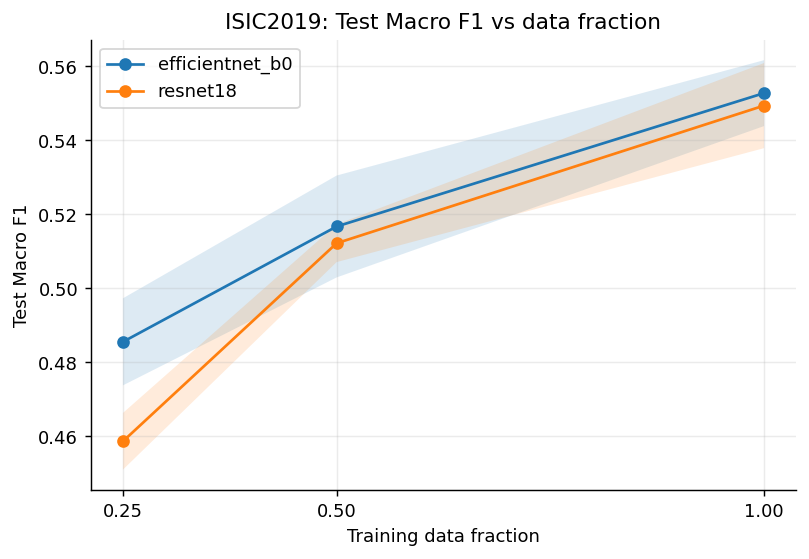

Saved: ISIC2019_sample_efficiency_auroc.png, ISIC2019_sample_efficiency_auroc.pdf


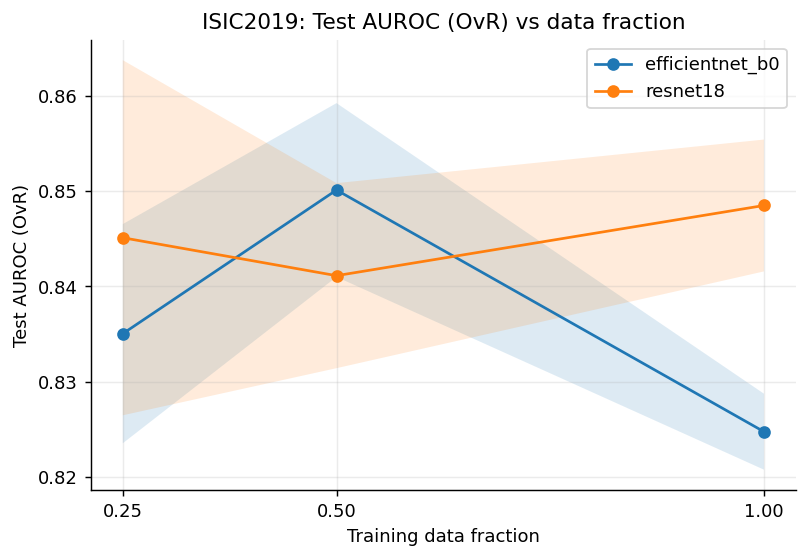

Saved: Messidor2_sample_efficiency_macro_f1.png, Messidor2_sample_efficiency_macro_f1.pdf


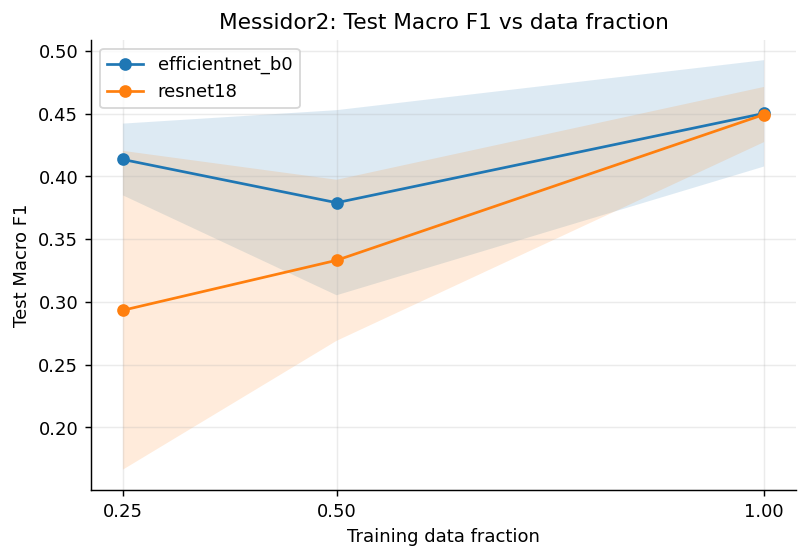

Saved: Messidor2_sample_efficiency_auroc.png, Messidor2_sample_efficiency_auroc.pdf


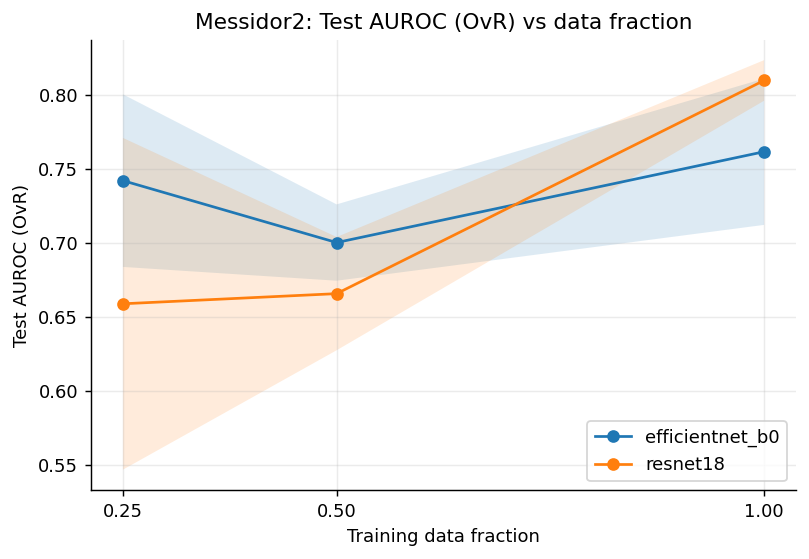

In [ ]:
def plot_metric_vs_fraction(df, metric, dataset_name, title_suffix="", save_name=None):
    d = df[df["dataset"] == dataset_name].copy()
    if len(d) == 0:
        print(f"No rows for dataset={dataset_name}")
        return

    g = (
        d.groupby(["model","data_fraction_used"])[metric]
        .agg(["mean","std","count"])
        .reset_index()
        .sort_values(["model","data_fraction_used"])
    )

    plt.figure(figsize=(7,4.5))
    for model_name in MODEL_ORDER:
        sub = g[g["model"] == model_name].sort_values("data_fraction_used")
        if len(sub) == 0:
            continue
        plt.plot(sub["data_fraction_used"], sub["mean"], marker="o", label=model_name)
        plt.fill_between(
            sub["data_fraction_used"].astype(float).to_numpy(),
            (sub["mean"] - sub["std"].fillna(0)).to_numpy(),
            (sub["mean"] + sub["std"].fillna(0)).to_numpy(),
            alpha=0.15
        )
    plt.xlabel("Training data fraction")
    plt.ylabel(pretty_metric_name(metric))
    plt.title(f"{dataset_name}: {pretty_metric_name(metric)} vs data fraction{title_suffix}")
    plt.xticks(FRACTION_ORDER)
    plt.legend()
    plt.grid(alpha=0.25)
    if save_name:
        save_current_fig(save_name)
    plt.show()

for ds in DATASET_ORDER:
    plot_metric_vs_fraction(final_df, "test_f1_macro", ds, save_name=f"{ds}_sample_efficiency_macro_f1")
    plot_metric_vs_fraction(final_df, "test_auroc_ovr", ds, save_name=f"{ds}_sample_efficiency_auroc")

In [ ]:
# Gains from lower to higher data fractions

gain_rows = []
for (dataset, model), sub in final_df.groupby(["dataset","model"]):
    stats_by_frac = sub.groupby("data_fraction_used")[PRIMARY_METRIC].mean().to_dict()
    ordered = sorted(stats_by_frac.items())
    for i in range(1, len(ordered)):
        prev_frac, prev_val = ordered[i-1]
        frac, val = ordered[i]
        gain_rows.append({
            "dataset": dataset,
            "model": model,
            "from_fraction": prev_frac,
            "to_fraction": frac,
            "mean_metric_prev": prev_val,
            "mean_metric_new": val,
            "absolute_gain": val - prev_val,
            "relative_gain_pct": (100 * (val - prev_val) / prev_val) if prev_val not in [0, np.nan] else np.nan
        })

gain_df = pd.DataFrame(gain_rows)
display(gain_df)
gain_df.to_csv(TABLE_DIR / "sample_efficiency_gains.csv", index=False)

,dataset,model,from_fraction,to_fraction,mean_metric_prev,mean_metric_new,absolute_gain,relative_gain_pct
0,ISIC2019,efficientnet_b0,0.25,0.5,0.485556,0.516733,0.031177,6.420903
1,ISIC2019,efficientnet_b0,0.50,1.0,0.516733,0.552777,0.036043,6.975256
2,ISIC2019,resnet18,0.25,0.5,0.458677,0.512207,0.053529,11.670376
3,ISIC2019,resnet18,0.50,1.0,0.512207,0.549405,0.037198,7.262273
4,Messidor2,efficientnet_b0,0.25,0.5,0.413503,0.379060,-0.034443,-8.329549
5,Messidor2,efficientnet_b0,0.50,1.0,0.379060,0.450266,0.071206,18.784844
6,Messidor2,resnet18,0.25,0.5,0.293345,0.333175,0.039830,13.577725
7,Messidor2,resnet18,0.50,1.0,0.333175,0.449345,0.116170,34.867530


## 6a. Descriptive curve fit

In [ ]:
def log_curve(x, a, b):
    return a + b * np.log(x)

curve_rows = []
for (dataset, model), sub in final_df.groupby(["dataset","model"]):
    grp = sub.groupby("data_fraction_used")[PRIMARY_METRIC].mean().reset_index()
    x = grp["data_fraction_used"].astype(float).to_numpy()
    y = grp[PRIMARY_METRIC].astype(float).to_numpy()
    if len(x) >= 3 and np.all(x > 0):
        try:
            popt, _ = curve_fit(log_curve, x, y, maxfev=10000)
            yhat = log_curve(x, *popt)
            ss_res = np.sum((y - yhat)**2)
            ss_tot = np.sum((y - y.mean())**2)
            r2 = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan
            curve_rows.append({
                "dataset": dataset,
                "model": model,
                "curve_a": popt[0],
                "curve_b": popt[1],
                "r2": r2
            })
        except Exception:
            pass

curve_df = pd.DataFrame(curve_rows)
display(curve_df)
curve_df.to_csv(TABLE_DIR / "descriptive_log_curve_fit.csv", index=False)

,dataset,model,curve_a,curve_b,r2
0,ISIC2019,efficientnet_b0,0.551966,0.048489,0.998256
1,ISIC2019,resnet18,0.552126,0.065446,0.989315
2,Messidor2,efficientnet_b0,0.432658,0.026519,0.266462
3,Messidor2,resnet18,0.436621,0.112530,0.926076


## 7. Direct model comparison

In [ ]:
pairwise_rows = []

for dataset in DATASET_ORDER:
    sub_d = final_df[final_df["dataset"] == dataset]
    models = sorted(sub_d["model"].dropna().unique().tolist())
    if len(models) < 2:
        continue
    base = models[0]
    for other in models[1:]:
        for frac in sorted(sub_d["data_fraction_used"].dropna().unique()):
            a = sub_d[(sub_d["model"] == base) & (sub_d["data_fraction_used"] == frac)][PRIMARY_METRIC].dropna().astype(float)
            b = sub_d[(sub_d["model"] == other) & (sub_d["data_fraction_used"] == frac)][PRIMARY_METRIC].dropna().astype(float)
            if len(a) == 0 or len(b) == 0:
                continue
            diff = b.mean() - a.mean()
            pooled_sd = np.sqrt(((a.std(ddof=1) ** 2) + (b.std(ddof=1) ** 2)) / 2) if len(a) > 1 and len(b) > 1 else np.nan
            cohen_d = diff / pooled_sd if pooled_sd and not np.isclose(pooled_sd, 0) else np.nan
            pairwise_rows.append({
                "dataset": dataset,
                "fraction": frac,
                "model_a": base,
                "model_b": other,
                f"{PRIMARY_METRIC}_mean_a": a.mean(),
                f"{PRIMARY_METRIC}_mean_b": b.mean(),
                "mean_difference_b_minus_a": diff,
                "cohens_d": cohen_d,
                "n_a": len(a),
                "n_b": len(b),
            })

pairwise_df = pd.DataFrame(pairwise_rows)
display(pairwise_df)
pairwise_df.to_csv(TABLE_DIR / "pairwise_model_comparison.csv", index=False)

,dataset,fraction,model_a,model_b,test_f1_macro_mean_a,test_f1_macro_mean_b,mean_difference_b_minus_a,cohens_d,n_a,n_b
0,ISIC2019,0.25,efficientnet_b0,resnet18,0.485556,0.458677,-0.026879,-2.708665,3,3
1,ISIC2019,0.50,efficientnet_b0,resnet18,0.516733,0.512207,-0.004527,-0.436080,3,3
2,ISIC2019,1.00,efficientnet_b0,resnet18,0.552777,0.549405,-0.003372,-0.327887,3,3
3,Messidor2,0.25,efficientnet_b0,resnet18,0.413503,0.293345,-0.120158,-1.305220,3,3
4,Messidor2,0.50,efficientnet_b0,resnet18,0.379060,0.333175,-0.045885,-0.663813,3,3
5,Messidor2,1.00,efficientnet_b0,resnet18,0.450266,0.449345,-0.000921,-0.027289,3,3


## 8. Parameter efficiency

In [ ]:
final_df["params_millions"] = final_df["total_params"] / 1_000_000
final_df["macro_f1_per_mparam"] = final_df["test_f1_macro"] / final_df["params_millions"]
final_df["auroc_per_mparam"] = final_df["test_auroc_ovr"] / final_df["params_millions"]

param_eff_df = mean_std_summary(
    final_df,
    ["dataset", "model", "data_fraction_used", "params_millions"],
    ["test_f1_macro", "test_auroc_ovr", "macro_f1_per_mparam", "auroc_per_mparam"]
).sort_values(["dataset","model","data_fraction_used"])

display(param_eff_df)
param_eff_df.to_csv(TABLE_DIR / "parameter_efficiency_summary.csv", index=False)

,dataset,model,data_fraction_used,params_millions,test_f1_macro_mean,test_f1_macro_std,test_f1_macro_min,test_f1_macro_max,test_f1_macro_count,test_auroc_ovr_mean,...,macro_f1_per_mparam_mean,macro_f1_per_mparam_std,macro_f1_per_mparam_min,macro_f1_per_mparam_max,macro_f1_per_mparam_count,auroc_per_mparam_mean,auroc_per_mparam_std,auroc_per_mparam_min,auroc_per_mparam_max,auroc_per_mparam_count
0,ISIC2019,efficientnet_b0,0.25,4.017796,0.485556,0.011760,0.475252,0.498367,3,0.835041,...,0.120851,0.002927,0.118287,0.124040,3,0.207836,0.002864,0.206053,0.211140,3
1,ISIC2019,efficientnet_b0,0.50,4.017796,0.516733,0.013767,0.501065,0.526895,3,0.850129,...,0.128611,0.003427,0.124711,0.131140,3,0.211591,0.002271,0.209173,0.213680,3
2,ISIC2019,efficientnet_b0,1.00,4.017796,0.552777,0.008904,0.542586,0.559051,3,0.824750,...,0.137582,0.002216,0.135046,0.139144,3,0.205274,0.000993,0.204286,0.206272,3
3,ISIC2019,resnet18,0.25,11.180616,0.458677,0.007658,0.454115,0.467519,3,0.845119,...,0.041024,0.000685,0.040616,0.041815,3,0.075588,0.001668,0.073773,0.077053,3
4,ISIC2019,resnet18,0.50,11.180616,0.512207,0.005095,0.509059,0.518085,3,0.841135,...,0.045812,0.000456,0.045530,0.046338,3,0.075232,0.000869,0.074399,0.076133,3
5,ISIC2019,resnet18,1.00,11.180616,0.549405,0.011501,0.538847,0.561661,3,0.848505,...,0.049139,0.001029,0.048195,0.050235,3,0.075891,0.000619,0.075530,0.076606,3
6,Messidor2,efficientnet_b0,0.25,4.013953,0.413503,0.028580,0.380862,0.434032,3,0.742322,...,0.103016,0.007120,0.094884,0.108131,3,0.184935,0.014539,0.173579,0.201322,3
7,Messidor2,efficientnet_b0,0.50,4.013953,0.379060,0.073748,0.294693,0.431262,3,0.700439,...,0.094436,0.018373,0.073417,0.107441,3,0.174501,0.006430,0.169517,0.181759,3
8,Messidor2,efficientnet_b0,1.00,4.013953,0.450266,0.042378,0.424708,0.499183,3,0.761858,...,0.112175,0.010558,0.105808,0.124362,3,0.189802,0.012327,0.176323,0.200504,3
9,Messidor2,resnet18,0.25,11.179077,0.293345,0.127016,0.218489,0.440000,3,0.659034,...,0.026241,0.011362,0.019544,0.039359,3,0.058952,0.010035,0.052413,0.070506,3


Saved: ISIC2019_parameter_efficiency_macro_f1_per_mparam.png, ISIC2019_parameter_efficiency_macro_f1_per_mparam.pdf


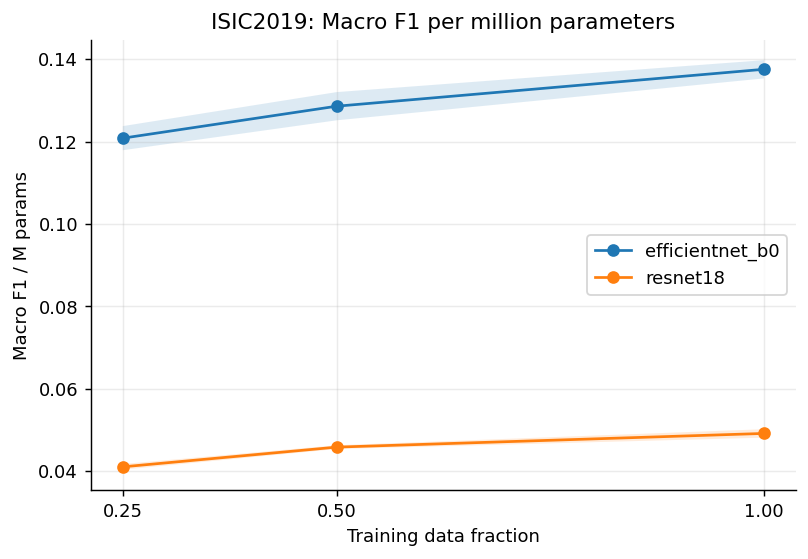

Saved: Messidor2_parameter_efficiency_macro_f1_per_mparam.png, Messidor2_parameter_efficiency_macro_f1_per_mparam.pdf


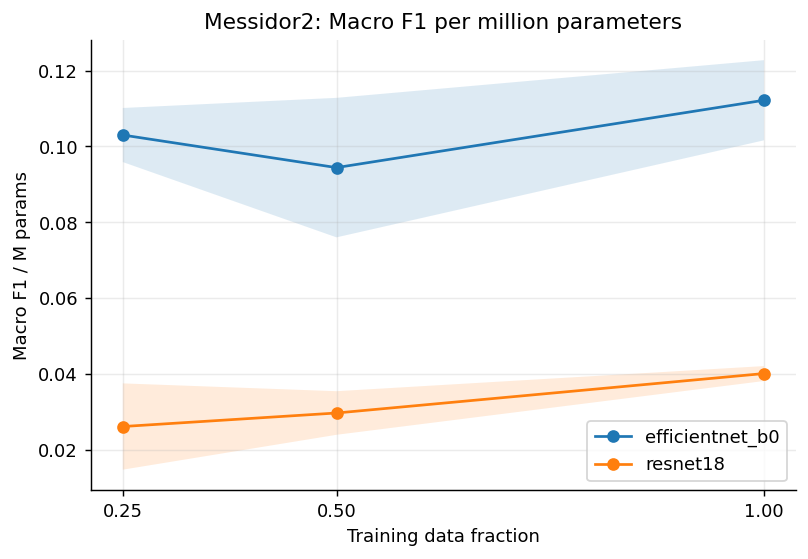

In [ ]:
for ds in DATASET_ORDER:
    sub = (
        final_df[final_df["dataset"] == ds]
        .groupby(["model","data_fraction_used"])["macro_f1_per_mparam"]
        .agg(["mean","std"])
        .reset_index()
    )
    plt.figure(figsize=(7,4.5))
    for model_name in MODEL_ORDER:
        ss = sub[sub["model"] == model_name].sort_values("data_fraction_used")
        if len(ss) == 0:
            continue
        plt.plot(ss["data_fraction_used"], ss["mean"], marker="o", label=model_name)
        plt.fill_between(
            ss["data_fraction_used"].astype(float).to_numpy(),
            (ss["mean"] - ss["std"].fillna(0)).to_numpy(),
            (ss["mean"] + ss["std"].fillna(0)).to_numpy(),
            alpha=0.15
        )
    plt.title(f"{ds}: Macro F1 per million parameters")
    plt.xlabel("Training data fraction")
    plt.ylabel("Macro F1 / M params")
    plt.xticks(FRACTION_ORDER)
    plt.legend()
    plt.grid(alpha=0.25)
    save_current_fig(f"{ds}_parameter_efficiency_macro_f1_per_mparam")
    plt.show()

## 9. Convergence and overfitting

In [ ]:
# Derive generalisation gaps at the final recorded epoch per run

if len(history_df):
    last_epoch_df = (
        history_df.sort_values(["run_id","epoch"])
        .groupby("run_id")
        .tail(1)
        .copy()
    )
    last_epoch_df["final_gap_acc"] = last_epoch_df["train_acc"] - last_epoch_df["val_acc"]
    last_epoch_df["final_gap_f1_macro"] = last_epoch_df["train_f1_macro"] - last_epoch_df["val_f1_macro"]
else:
    last_epoch_df = pd.DataFrame()

display(last_epoch_df.head())

,epoch,run_id,dataset,model,seed,data_fraction_requested,data_fraction_used,train_loss,train_acc,train_f1_macro,...,val_f1_weighted,val_auroc_ovr,val_n_seen,lr,best_val_loss_so_far,best_epoch_so_far,patience_counter,_source_json,final_gap_acc,final_gap_f1_macro
22,23,ISIC2019_efficientnet_b0_100_42,ISIC2019,efficientnet_b0,42,1.00,1.00,0.917321,0.982925,0.973687,...,0.853894,0.946581,5067,0.000025,0.895018,18,5,/content/drive/MyDrive/MSC_Research/CNNs/Resul...,0.129363,0.187789
47,25,ISIC2019_efficientnet_b0_100_43,ISIC2019,efficientnet_b0,43,1.00,1.00,0.921495,0.984899,0.980971,...,0.854278,0.941264,5067,0.000050,0.887078,23,2,/content/drive/MyDrive/MSC_Research/CNNs/Resul...,0.131534,0.193413
72,25,ISIC2019_efficientnet_b0_100_44,ISIC2019,efficientnet_b0,44,1.00,1.00,0.926416,0.985985,0.981733,...,0.854344,0.944377,5067,0.000050,0.893080,25,0,/content/drive/MyDrive/MSC_Research/CNNs/Resul...,0.131436,0.203171
89,17,ISIC2019_efficientnet_b0_25_42,ISIC2019,efficientnet_b0,42,0.25,0.25,0.963953,0.952221,0.897799,...,0.754450,0.913319,1267,0.000050,1.102625,12,5,/content/drive/MyDrive/MSC_Research/CNNs/Resul...,0.203997,0.331900
107,18,ISIC2019_efficientnet_b0_25_43,ISIC2019,efficientnet_b0,43,0.25,0.25,0.961974,0.957947,0.917616,...,0.743072,0.913817,1267,0.000050,1.167470,13,5,/content/drive/MyDrive/MSC_Research/CNNs/Resul...,0.225508,0.338300


In [ ]:
convergence_summary = (
    final_df[[
        "run_id","dataset","model","seed","data_fraction_used","best_epoch","epochs_trained","stopped_early","run_seconds"
    ]]
    .merge(
        last_epoch_df[["run_id","final_gap_acc","final_gap_f1_macro"]] if len(last_epoch_df) else pd.DataFrame(columns=["run_id"]),
        on="run_id",
        how="left"
    )
)

convergence_grouped = mean_std_summary(
    convergence_summary,
    ["dataset","model","data_fraction_used"],
    ["best_epoch","epochs_trained","stopped_early","run_seconds","final_gap_acc","final_gap_f1_macro"]
)

display(convergence_grouped)
convergence_grouped.to_csv(TABLE_DIR / "convergence_summary.csv", index=False)

,dataset,model,data_fraction_used,best_epoch_mean,best_epoch_std,best_epoch_min,best_epoch_max,best_epoch_count,epochs_trained_mean,epochs_trained_std,...,final_gap_acc_mean,final_gap_acc_std,final_gap_acc_min,final_gap_acc_max,final_gap_acc_count,final_gap_f1_macro_mean,final_gap_f1_macro_std,final_gap_f1_macro_min,final_gap_f1_macro_max,final_gap_f1_macro_count
0,ISIC2019,efficientnet_b0,0.25,13.000000,1.000000,12,14,3,18.000000,1.000000,...,0.215904,0.010939,0.203997,0.225508,3,0.349955,0.025928,0.331900,0.379665,3
1,ISIC2019,efficientnet_b0,0.50,10.000000,0.000000,10,10,3,15.000000,0.000000,...,0.176372,0.005020,0.170647,0.180024,3,0.278126,0.010883,0.266154,0.287419,3
2,ISIC2019,efficientnet_b0,1.00,22.000000,3.605551,18,25,3,24.333333,1.154701,...,0.130778,0.001226,0.129363,0.131534,3,0.194791,0.007783,0.187789,0.203171,3
3,ISIC2019,resnet18,0.25,9.666667,0.577350,9,10,3,14.666667,0.577350,...,0.127832,0.028586,0.095014,0.147305,3,0.201008,0.043364,0.162626,0.248047,3
4,ISIC2019,resnet18,0.50,18.000000,3.605551,15,22,3,22.333333,2.516611,...,0.178181,0.022102,0.162258,0.203415,3,0.243915,0.029023,0.216182,0.274076,3
5,ISIC2019,resnet18,1.00,18.666667,8.504901,9,25,3,21.333333,6.350853,...,0.128728,0.024561,0.100825,0.147072,3,0.184344,0.030801,0.149615,0.208350,3
6,Messidor2,efficientnet_b0,0.25,17.333333,10.785793,5,25,3,20.000000,8.660254,...,0.462543,0.037369,0.419393,0.484118,3,0.592105,0.119188,0.455613,0.675622,3
7,Messidor2,efficientnet_b0,0.50,14.333333,1.154701,13,15,3,19.333333,1.154701,...,0.410517,0.046426,0.358013,0.446143,3,0.549029,0.040208,0.506474,0.586384,3
8,Messidor2,efficientnet_b0,1.00,13.333333,0.577350,13,14,3,18.333333,0.577350,...,0.368158,0.043868,0.339767,0.418684,3,0.436533,0.037575,0.402676,0.476960,3
9,Messidor2,resnet18,0.25,2.666667,0.577350,2,3,3,7.666667,0.577350,...,0.375886,0.099105,0.268689,0.464175,3,0.433202,0.093473,0.326792,0.502057,3


Saved: ISIC2019_learning_curve_val_f1_macro.png, ISIC2019_learning_curve_val_f1_macro.pdf


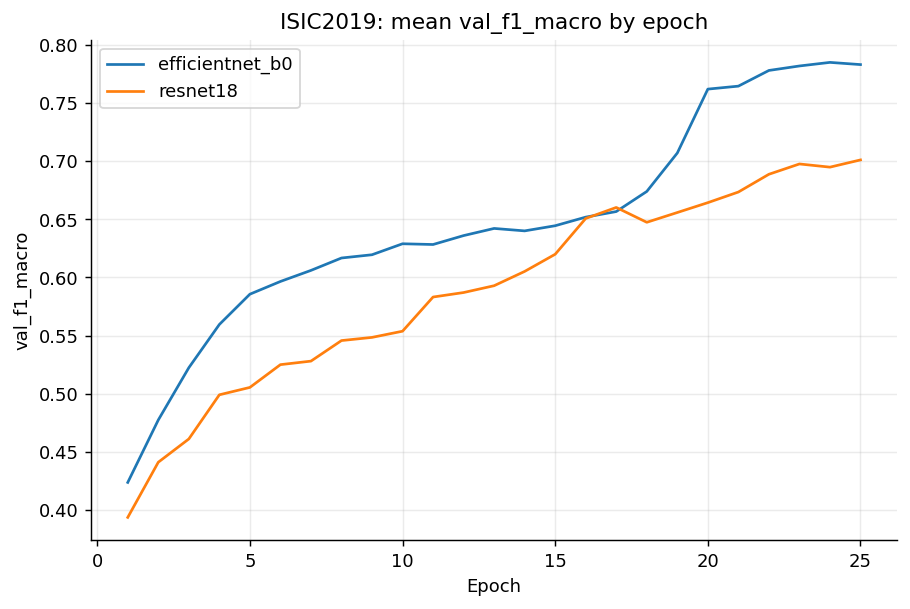

Saved: ISIC2019_learning_curve_val_loss.png, ISIC2019_learning_curve_val_loss.pdf


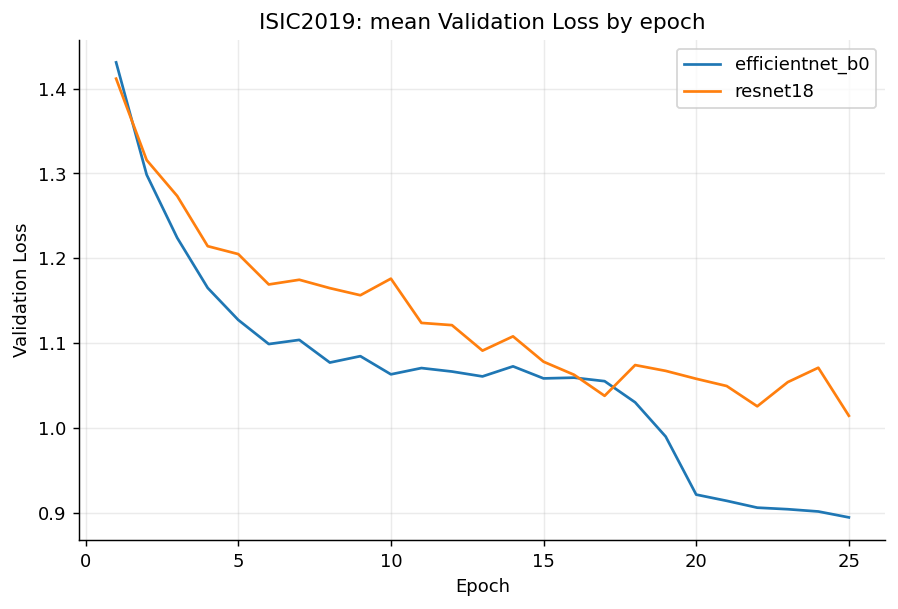

Saved: ISIC2019_learning_curve_train_loss.png, ISIC2019_learning_curve_train_loss.pdf


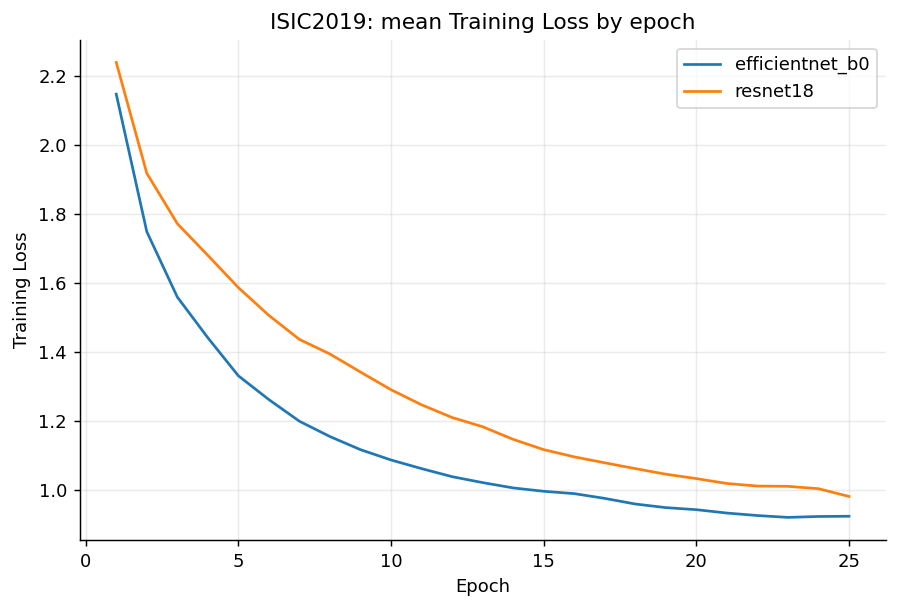

Saved: Messidor2_learning_curve_val_f1_macro.png, Messidor2_learning_curve_val_f1_macro.pdf


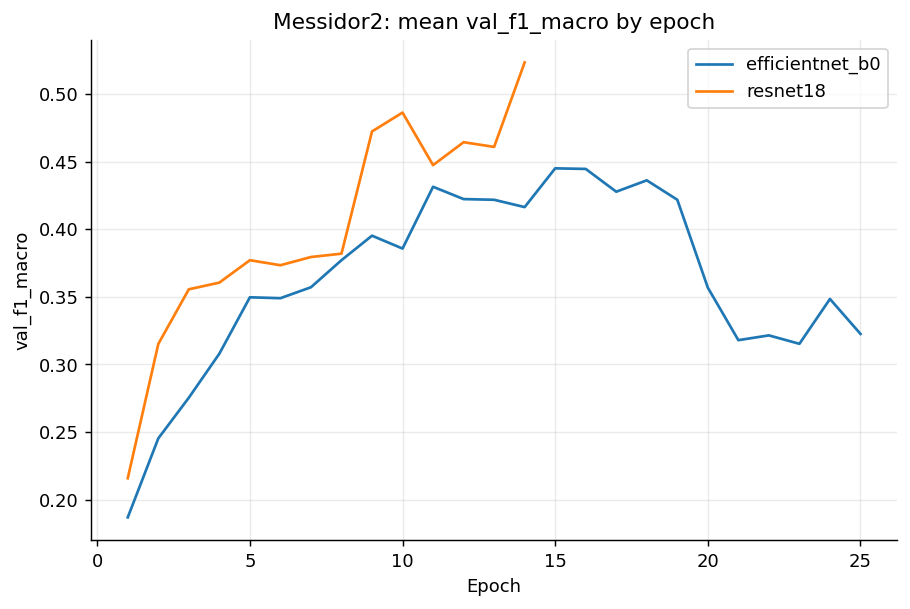

Saved: Messidor2_learning_curve_val_loss.png, Messidor2_learning_curve_val_loss.pdf


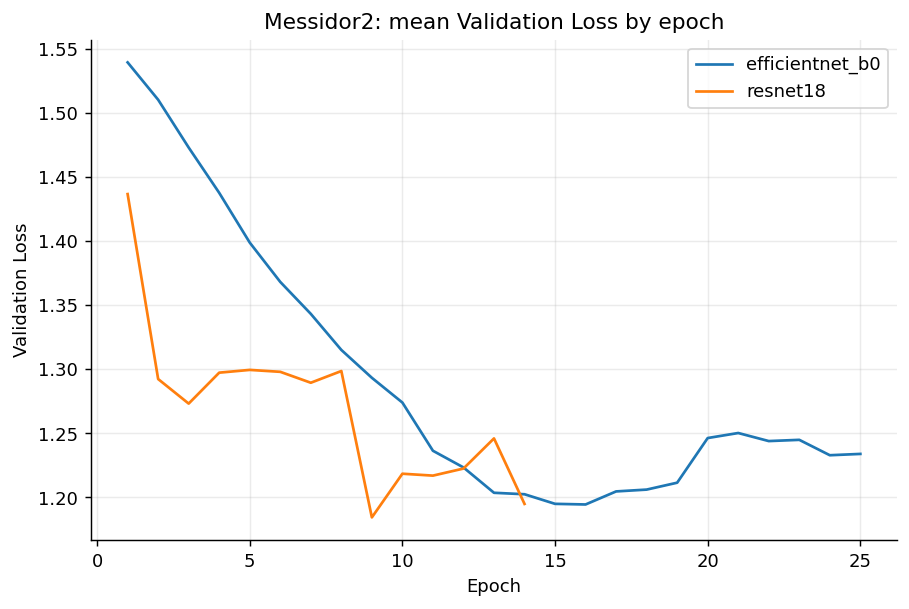

Saved: Messidor2_learning_curve_train_loss.png, Messidor2_learning_curve_train_loss.pdf


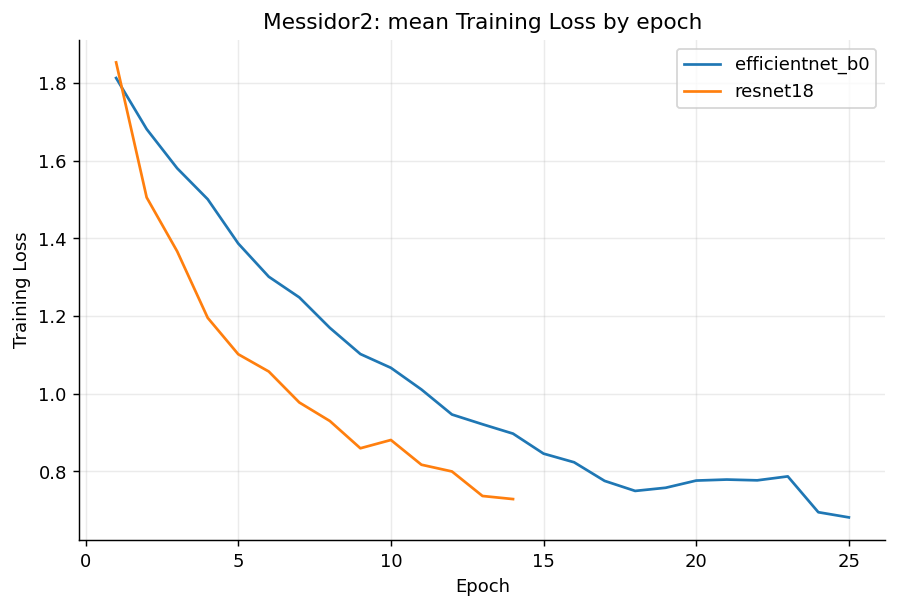

In [ ]:
def plot_learning_curves(history, dataset_name, metric="val_f1_macro", save_name=None):
    sub = history[history["dataset"] == dataset_name].copy()
    if len(sub) == 0:
        return

    plt.figure(figsize=(8,5))
    for model_name in MODEL_ORDER:
        ss = sub[sub["model"] == model_name].groupby("epoch")[metric].mean().reset_index()
        if len(ss) == 0:
            continue
        plt.plot(ss["epoch"], ss[metric], marker=None, label=model_name)
    plt.xlabel("Epoch")
    plt.ylabel(pretty_metric_name(metric))
    plt.title(f"{dataset_name}: mean {pretty_metric_name(metric)} by epoch")
    plt.legend()
    plt.grid(alpha=0.25)
    if save_name:
        save_current_fig(save_name)
    plt.show()

for ds in DATASET_ORDER:
    plot_learning_curves(history_df, ds, metric="val_f1_macro", save_name=f"{ds}_learning_curve_val_f1_macro")
    plot_learning_curves(history_df, ds, metric="val_loss", save_name=f"{ds}_learning_curve_val_loss")
    plot_learning_curves(history_df, ds, metric="train_loss", save_name=f"{ds}_learning_curve_train_loss")

Saved: ISIC2019_frac_0p25_val_f1_macro.png, ISIC2019_frac_0p25_val_f1_macro.pdf


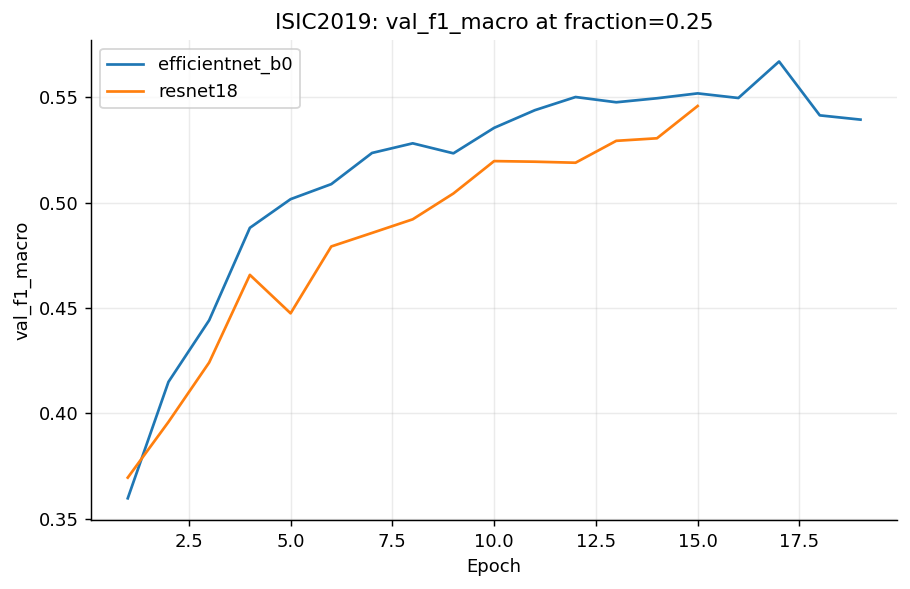

Saved: ISIC2019_frac_0p5_val_f1_macro.png, ISIC2019_frac_0p5_val_f1_macro.pdf


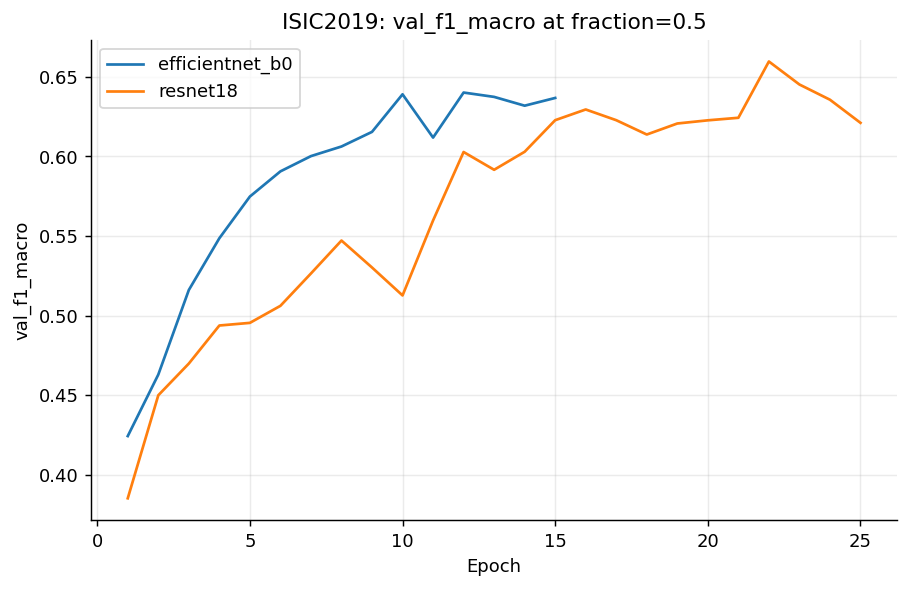

Saved: ISIC2019_frac_1p0_val_f1_macro.png, ISIC2019_frac_1p0_val_f1_macro.pdf


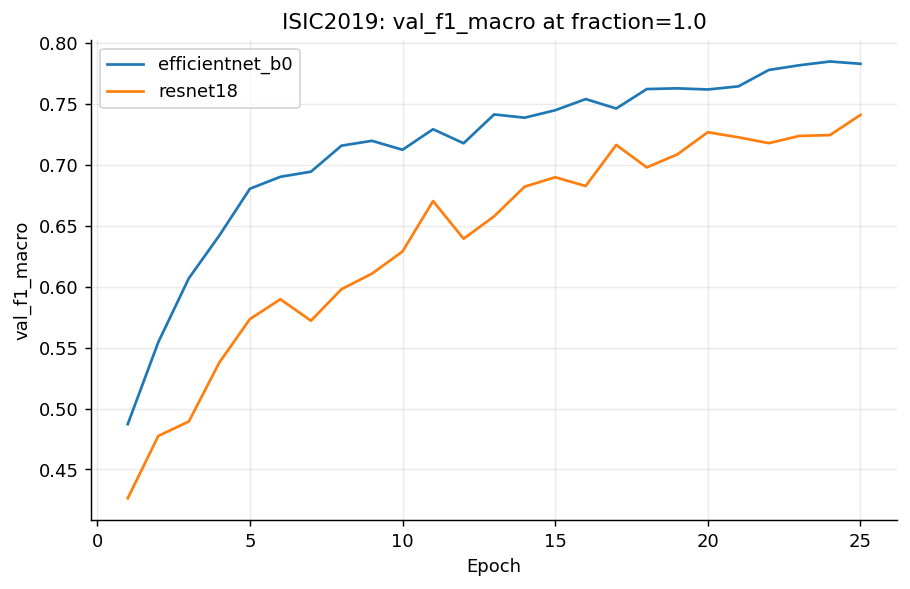

Saved: Messidor2_frac_0p25_val_f1_macro.png, Messidor2_frac_0p25_val_f1_macro.pdf


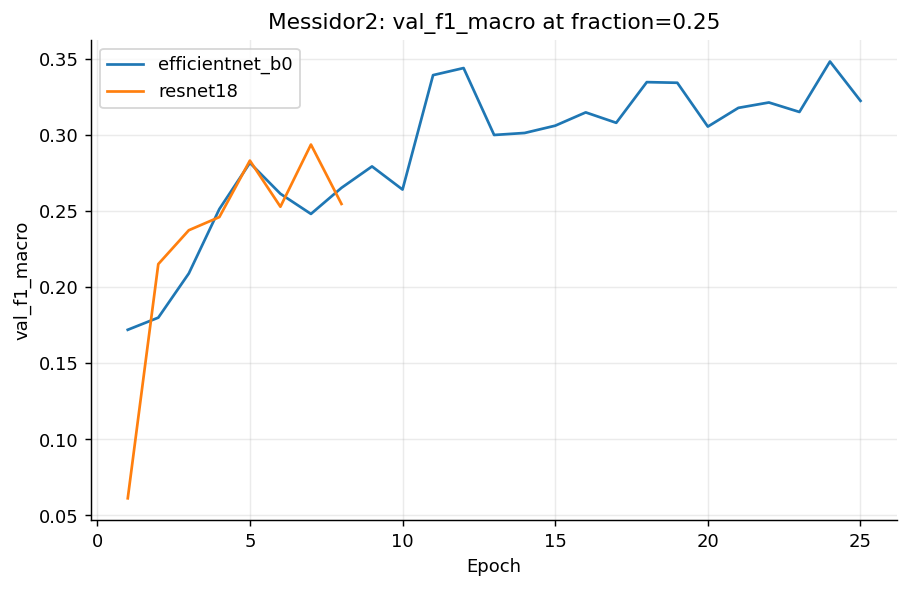

Saved: Messidor2_frac_0p5_val_f1_macro.png, Messidor2_frac_0p5_val_f1_macro.pdf


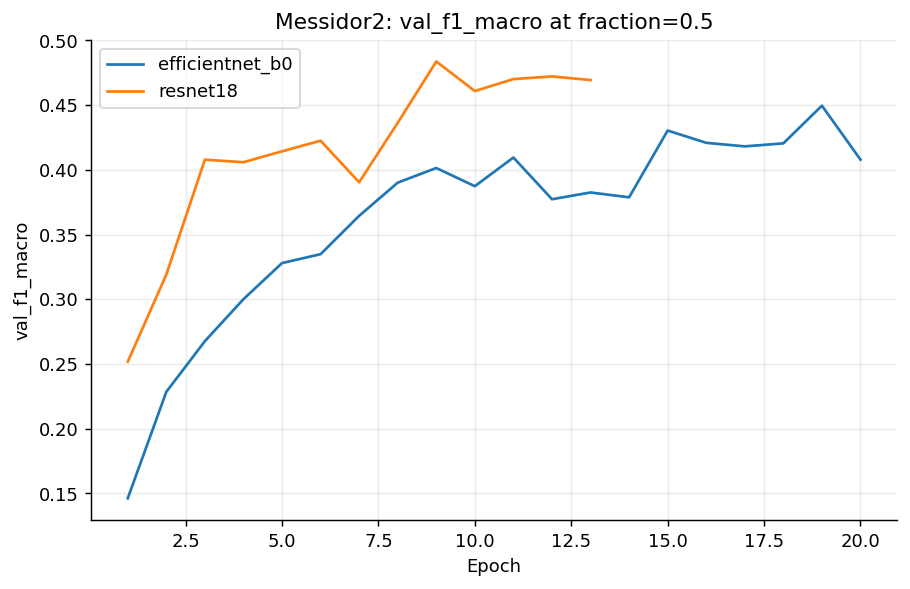

Saved: Messidor2_frac_1p0_val_f1_macro.png, Messidor2_frac_1p0_val_f1_macro.pdf


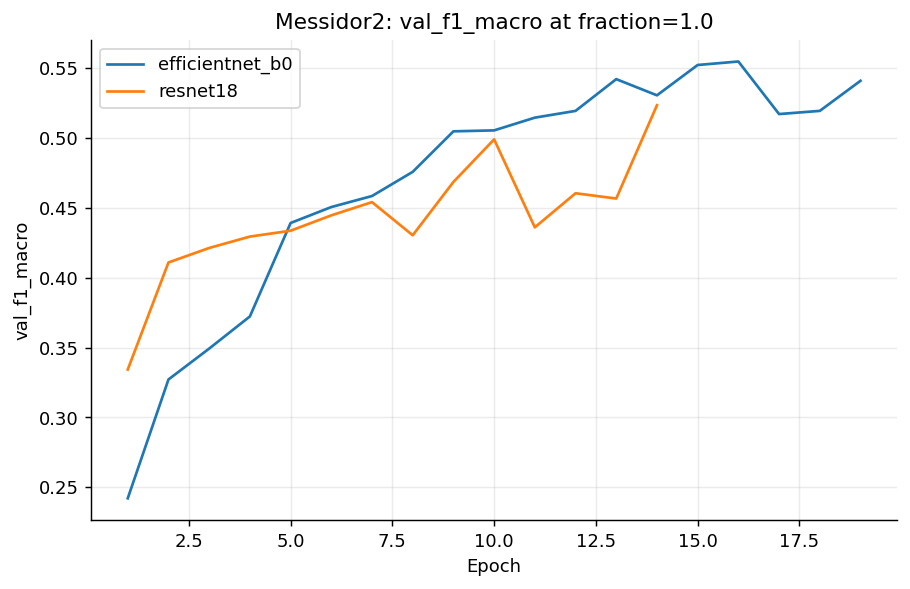

In [ ]:
# Learning curves split by fraction for finer comparison

def plot_learning_curves_by_fraction(history, dataset_name, metric="val_f1_macro"):
    sub = history[history["dataset"] == dataset_name].copy()
    fracs = sorted(sub["data_fraction_used"].dropna().unique().tolist())
    if len(sub) == 0:
        return

    for frac in fracs:
        plt.figure(figsize=(8,4.8))
        sf = sub[sub["data_fraction_used"] == frac]
        for model_name in MODEL_ORDER:
            ss = sf[sf["model"] == model_name].groupby("epoch")[metric].mean().reset_index()
            if len(ss) == 0:
                continue
            plt.plot(ss["epoch"], ss[metric], label=model_name)
        plt.title(f"{dataset_name}: {pretty_metric_name(metric)} at fraction={frac}")
        plt.xlabel("Epoch")
        plt.ylabel(pretty_metric_name(metric))
        plt.legend()
        plt.grid(alpha=0.25)
        save_current_fig(f"{dataset_name}_frac_{str(frac).replace('.','p')}_{metric}")
        plt.show()

for ds in DATASET_ORDER:
    plot_learning_curves_by_fraction(history_df, ds, metric="val_f1_macro")

## 10. Class-wise performance and confusion matrices

In [ ]:

# Per-class summary with dynamic grouping
rename_map = {}
if "f1-score" in per_class_df.columns:
    rename_map["f1-score"] = "f1_score"
per_class_df = per_class_df.rename(columns=rename_map)

if len(per_class_df):
    candidate_group_cols = ["dataset", "model", "data_fraction_used", "class_name", "class_id", "label"]
    group_cols = [c for c in candidate_group_cols if c in per_class_df.columns]
    metric_cols = [c for c in ["precision", "recall", "f1_score"] if c in per_class_df.columns]

    if not group_cols:
        print("Per-class table exists, but no grouping columns were found.")
    elif not metric_cols:
        print("Per-class table exists, but no metric columns were found.")
    else:
        per_class_summary = mean_std_summary(per_class_df, group_cols, metric_cols)
        display(per_class_summary.head(20))
        per_class_summary.to_csv(TABLE_DIR / "per_class_summary.csv", index=False)
else:
    print("No per-class table found in saved bundles.")


,dataset,model,data_fraction_used,class_id,precision_mean,precision_std,precision_min,precision_max,precision_count,recall_mean,recall_std,recall_min,recall_max,recall_count
0,ISIC2019,efficientnet_b0,0.25,0,0.365911,0.030520,0.331313,0.389016,3,0.437611,0.017397,0.419786,0.454545,3
1,ISIC2019,efficientnet_b0,0.25,1,0.616493,0.010808,0.604882,0.626263,3,0.687863,0.010871,0.677949,0.699487,3
2,ISIC2019,efficientnet_b0,0.25,2,0.441053,0.043583,0.412281,0.491197,3,0.406061,0.044096,0.356061,0.439394,3
3,ISIC2019,efficientnet_b0,0.25,3,0.233277,0.024463,0.206278,0.253968,3,0.512821,0.012689,0.505495,0.527473,3
4,ISIC2019,efficientnet_b0,0.25,4,0.636503,0.015740,0.618412,0.647059,3,0.632002,0.040451,0.586285,0.663150,3
5,ISIC2019,efficientnet_b0,0.25,5,0.858400,0.007559,0.851266,0.866323,3,0.742151,0.011736,0.731463,0.754709,3
6,ISIC2019,efficientnet_b0,0.25,6,0.249380,0.024276,0.223684,0.271930,3,0.329293,0.040354,0.303030,0.375758,3
7,ISIC2019,efficientnet_b0,0.25,7,0.324489,0.028498,0.304636,0.357143,3,0.461538,0.019231,0.442308,0.480769,3
8,ISIC2019,efficientnet_b0,0.50,0,0.351155,0.011499,0.340580,0.363395,3,0.369875,0.006175,0.366310,0.377005,3
9,ISIC2019,efficientnet_b0,0.50,1,0.627823,0.016251,0.609099,0.638259,3,0.722735,0.018471,0.704615,0.741538,3


In [ ]:
# Identify the best single run for each dataset x model x fraction using primary metric

best_runs = (
    final_df.sort_values(["dataset","model","data_fraction_used", PRIMARY_METRIC], ascending=[True,True,True,False])
    .groupby(["dataset","model","data_fraction_used"])
    .head(1)
    .copy()
)

display(best_runs[["run_id","dataset","model","data_fraction_used",PRIMARY_METRIC,"seed"]].sort_values(["dataset","model","data_fraction_used"]))
best_runs.to_csv(TABLE_DIR / "best_runs_by_condition.csv", index=False)

,run_id,dataset,model,data_fraction_used,test_f1_macro,seed
3,ISIC2019_efficientnet_b0_25_42,ISIC2019,efficientnet_b0,0.25,0.498367,42
7,ISIC2019_efficientnet_b0_50_43,ISIC2019,efficientnet_b0,0.50,0.526895,43
0,ISIC2019_efficientnet_b0_100_42,ISIC2019,efficientnet_b0,1.00,0.559051,42
12,ISIC2019_resnet18_25_42,ISIC2019,resnet18,0.25,0.467519,42
15,ISIC2019_resnet18_50_42,ISIC2019,resnet18,0.50,0.518085,42
11,ISIC2019_resnet18_100_44,ISIC2019,resnet18,1.00,0.561661,44
21,Messidor2_efficientnet_b0_25_42,Messidor2,efficientnet_b0,0.25,0.434032,42
25,Messidor2_efficientnet_b0_50_43,Messidor2,efficientnet_b0,0.50,0.431262,43
18,Messidor2_efficientnet_b0_100_42,Messidor2,efficientnet_b0,1.00,0.499183,42
31,Messidor2_resnet18_25_43,Messidor2,resnet18,0.25,0.440000,43


### ISIC2019 — efficientnet_b0 — fraction 0.25

Run ID: `ISIC2019_efficientnet_b0_25_42`

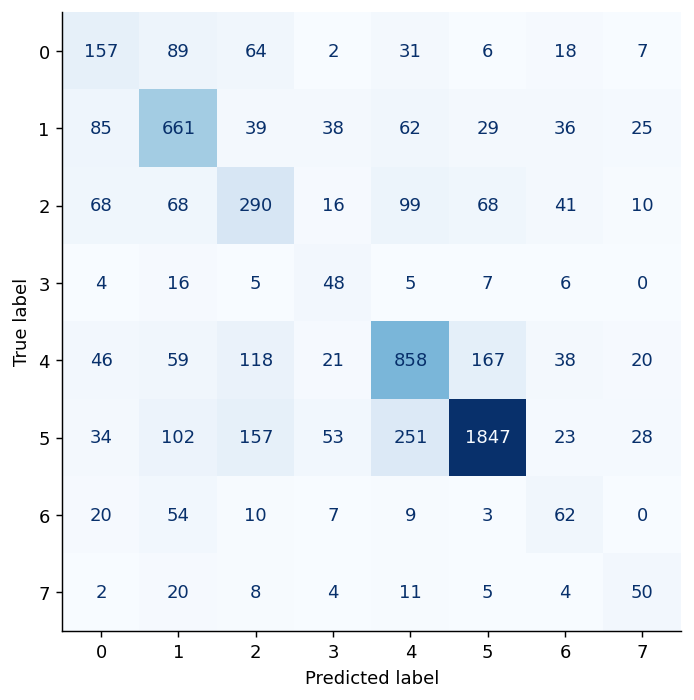

---

### ISIC2019 — resnet18 — fraction 0.25

Run ID: `ISIC2019_resnet18_25_42`

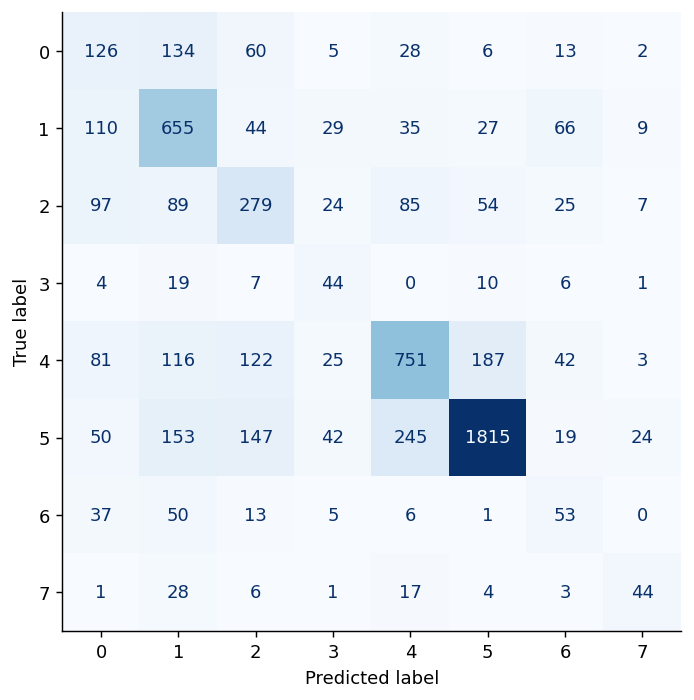

---

### ISIC2019 — efficientnet_b0 — fraction 0.5

Run ID: `ISIC2019_efficientnet_b0_50_43`

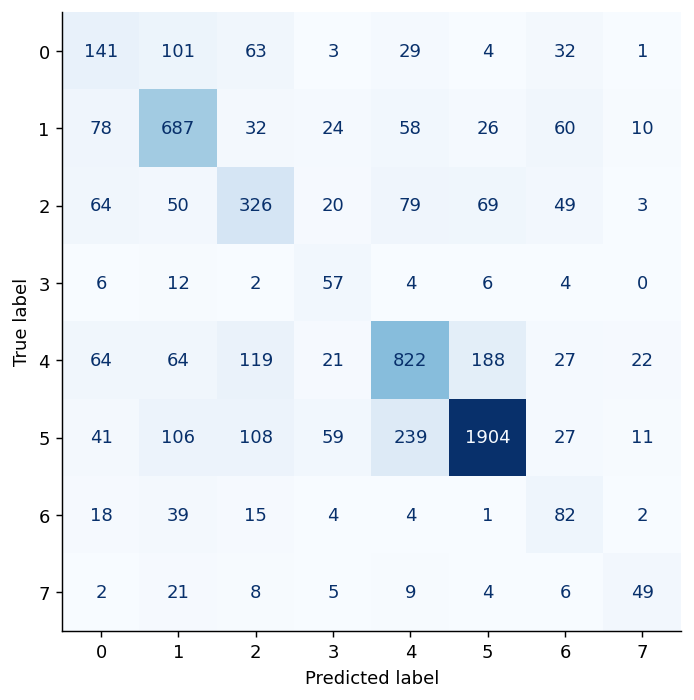

---

### ISIC2019 — resnet18 — fraction 0.5

Run ID: `ISIC2019_resnet18_50_42`

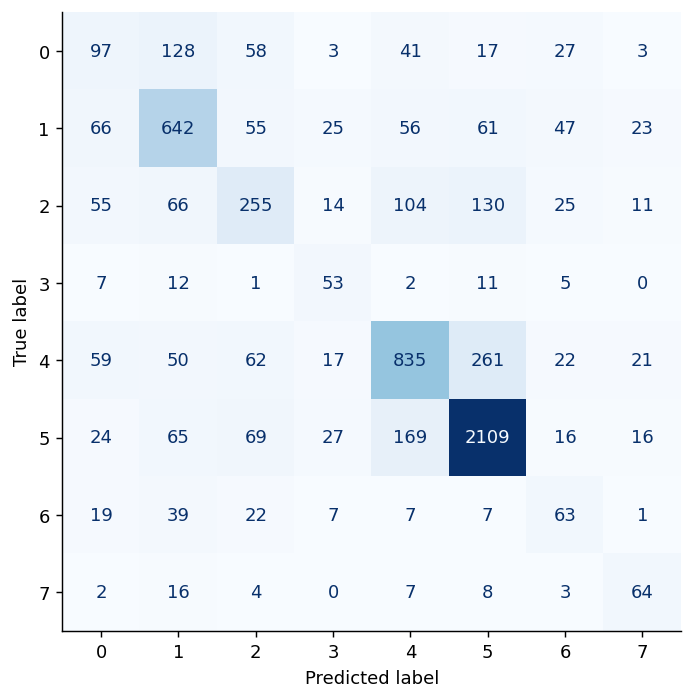

---

### ISIC2019 — efficientnet_b0 — fraction 1.0

Run ID: `ISIC2019_efficientnet_b0_100_42`

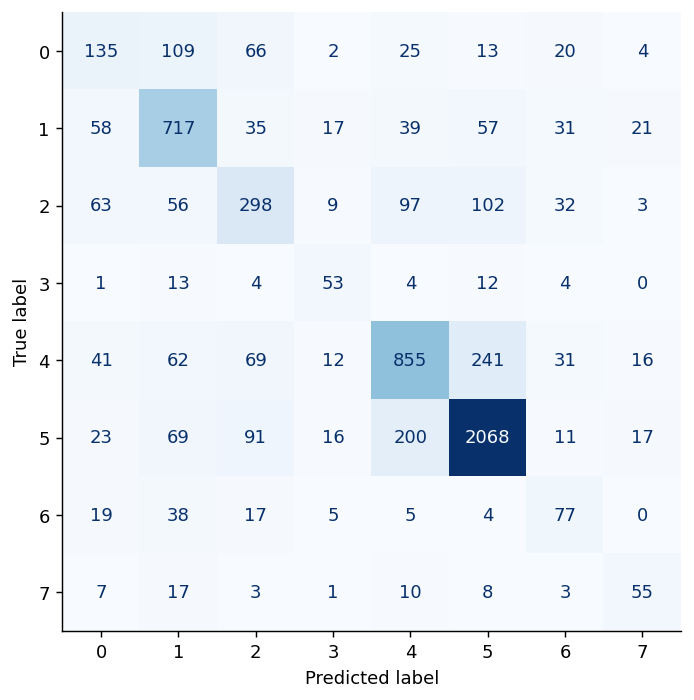

---

### ISIC2019 — resnet18 — fraction 1.0

Run ID: `ISIC2019_resnet18_100_44`

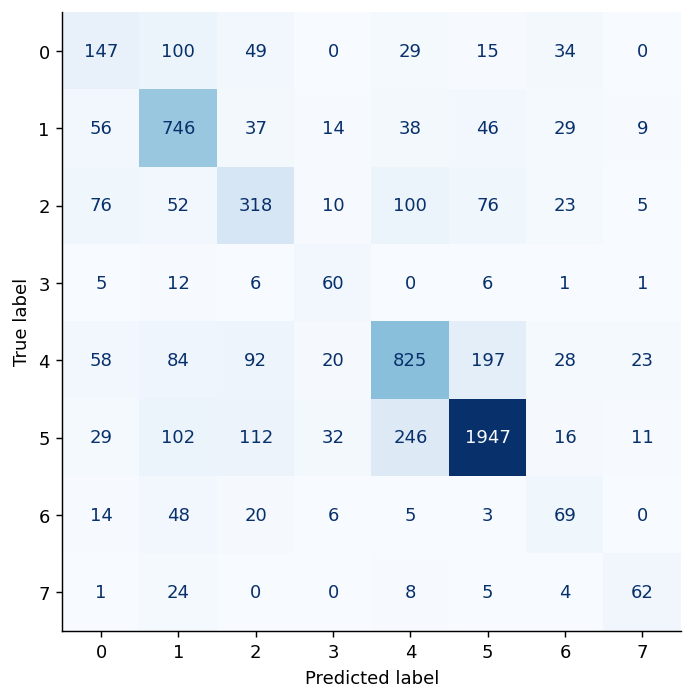

---

### Messidor2 — efficientnet_b0 — fraction 0.25

Run ID: `Messidor2_efficientnet_b0_25_42`

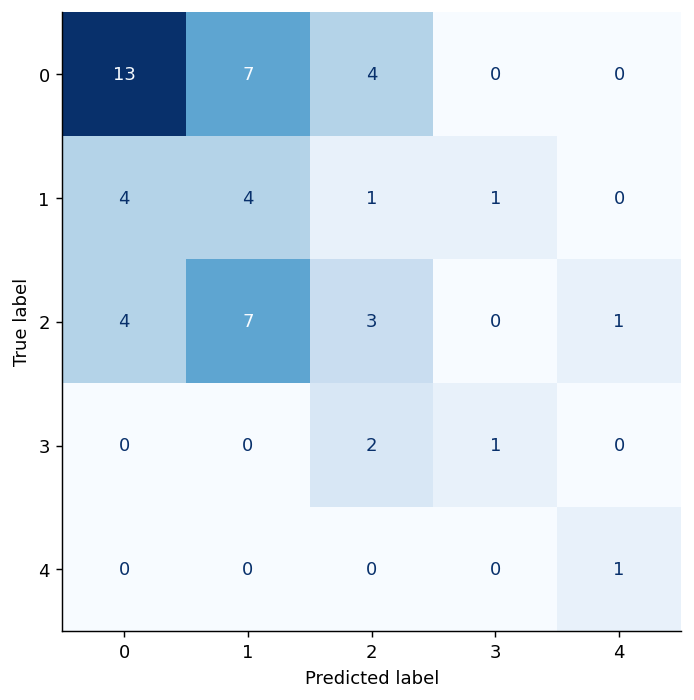

---

### Messidor2 — resnet18 — fraction 0.25

Run ID: `Messidor2_resnet18_25_43`

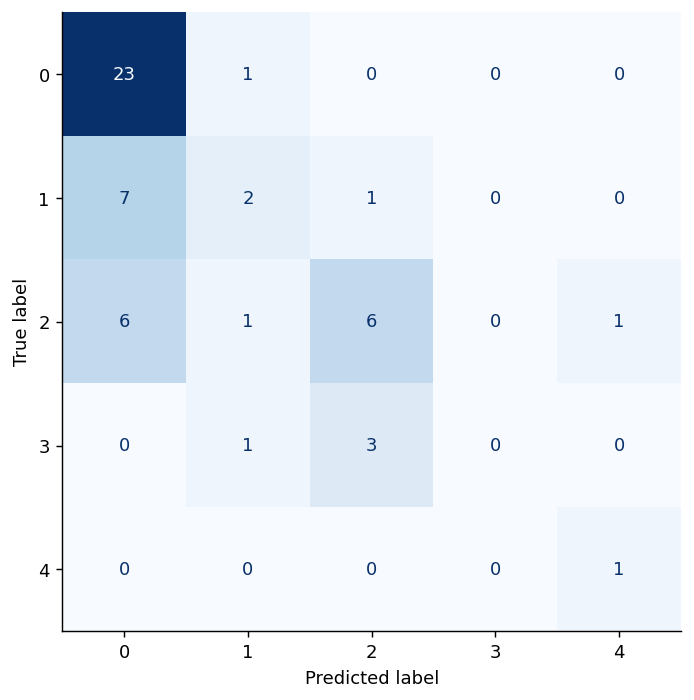

---

### Messidor2 — efficientnet_b0 — fraction 0.5

Run ID: `Messidor2_efficientnet_b0_50_43`

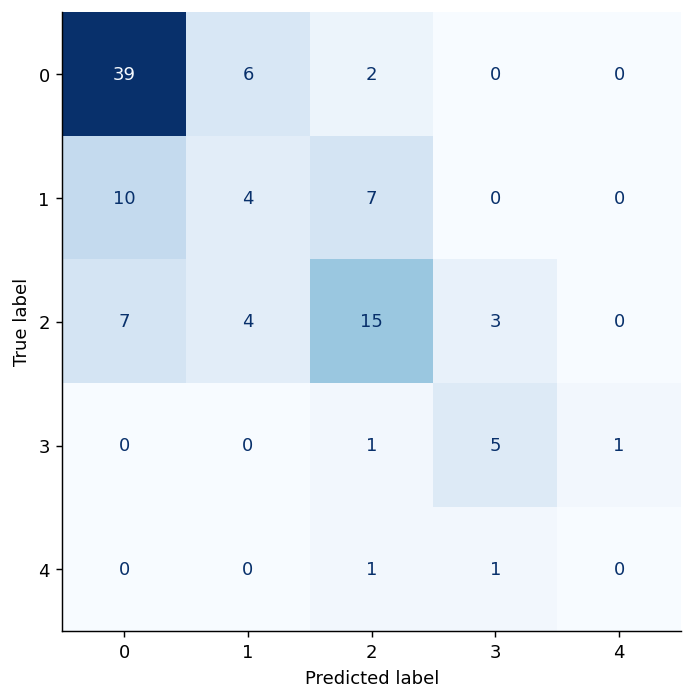

---

### Messidor2 — resnet18 — fraction 0.5

Run ID: `Messidor2_resnet18_50_43`

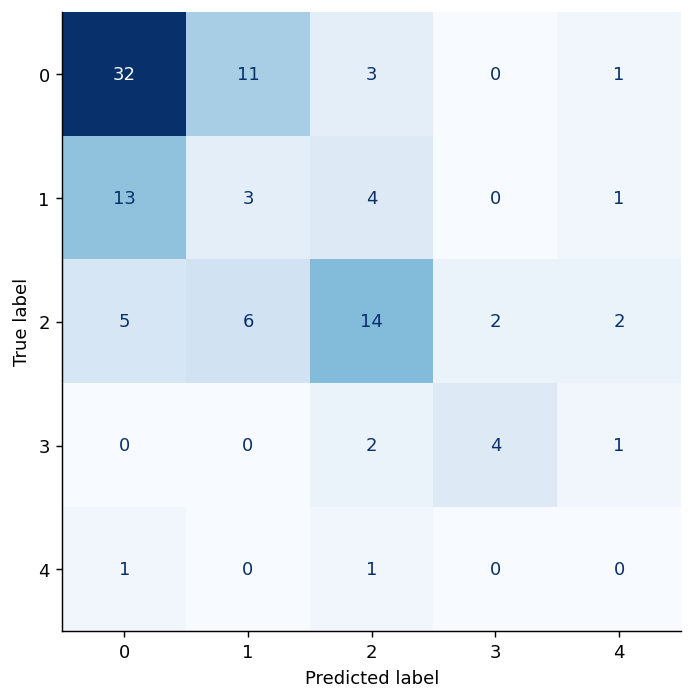

---

### Messidor2 — efficientnet_b0 — fraction 1.0

Run ID: `Messidor2_efficientnet_b0_100_42`

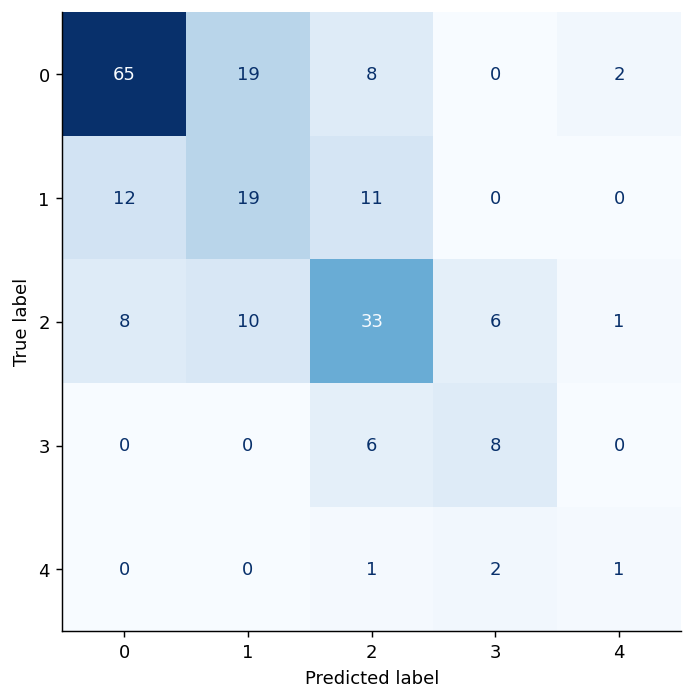

---

### Messidor2 — resnet18 — fraction 1.0

Run ID: `Messidor2_resnet18_100_44`

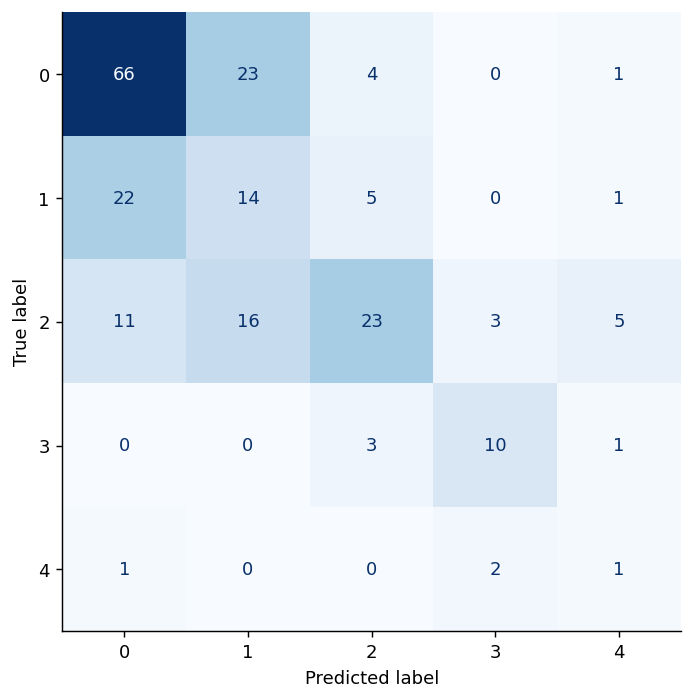

---

In [ ]:

# Plot confusion matrices for the best run in each condition

from IPython.display import Markdown, display

def plot_confusion_for_run(run_id):
    cm = confusion_store.get(run_id)
    if cm is None:
        print(f"No confusion matrix stored for {run_id}")
        return

    fig, ax = plt.subplots(figsize=(6.8, 5.8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
    ax.set_title("")
    ax.grid(False)
    plt.tight_layout(pad=2.2)
    plt.show()
    plt.close(fig)

sort_cols = [c for c in ["dataset", "data_fraction_used", "model"] if c in best_runs.columns]
plot_rows = best_runs.sort_values(sort_cols) if len(best_runs) and sort_cols else best_runs

for _, row in plot_rows.iterrows():
    header = f"### {row.get('dataset', 'NA')} — {row.get('model', 'NA')} — fraction {row.get('data_fraction_used', 'NA')}"
    subline = f"Run ID: `{row.get('run_id', 'NA')}`"
    display(Markdown(f"""{header}

{subline}"""))
    plot_confusion_for_run(row["run_id"])
    print()
    display(Markdown("---"))
    print()


## 11. Grad-CAM output omitted

Grad-CAM rendering cells were removed from this version.

## 13. Combined summary table

In [ ]:
chapter_table = (
    final_df.groupby(["dataset","model","data_fraction_used"])
    .agg(
        n_runs=("run_id","nunique"),
        macro_f1_mean=("test_f1_macro","mean"),
        macro_f1_std=("test_f1_macro","std"),
        auroc_mean=("test_auroc_ovr","mean"),
        auroc_std=("test_auroc_ovr","std"),
        acc_mean=("test_acc","mean"),
        acc_std=("test_acc","std"),
        params_m=("params_millions","mean"),
        macro_f1_per_mparam_mean=("macro_f1_per_mparam","mean"),
        best_epoch_mean=("best_epoch","mean"),
        epochs_trained_mean=("epochs_trained","mean"),
        stopped_early_rate=("stopped_early","mean"),
        run_seconds_mean=("run_seconds","mean"),
    )
    .reset_index()
    .sort_values(["dataset","model","data_fraction_used"])
)

for c in ["macro_f1_mean","macro_f1_std","auroc_mean","auroc_std","acc_mean","acc_std","params_m","macro_f1_per_mparam_mean","best_epoch_mean","epochs_trained_mean","stopped_early_rate","run_seconds_mean"]:
    chapter_table[c] = chapter_table[c].round(4)

display(chapter_table)
chapter_table.to_csv(TABLE_DIR / "cnn_chapter_master_table.csv", index=False)

,dataset,model,data_fraction_used,n_runs,macro_f1_mean,macro_f1_std,auroc_mean,auroc_std,acc_mean,acc_std,params_m,macro_f1_per_mparam_mean,best_epoch_mean,epochs_trained_mean,stopped_early_rate,run_seconds_mean
0,ISIC2019,efficientnet_b0,0.25,3,0.4856,0.0118,0.8350,0.0115,0.6367,0.0047,4.0178,0.1209,13.0000,18.0000,1.0000,2532.7616
1,ISIC2019,efficientnet_b0,0.50,3,0.5167,0.0138,0.8501,0.0091,0.6540,0.0069,4.0178,0.1286,10.0000,15.0000,1.0000,3765.1573
2,ISIC2019,efficientnet_b0,1.00,3,0.5528,0.0089,0.8247,0.0040,0.6888,0.0011,4.0178,0.1376,22.0000,24.3333,0.3333,11741.3110
3,ISIC2019,resnet18,0.25,3,0.4587,0.0077,0.8451,0.0186,0.6031,0.0049,11.1806,0.0410,9.6667,14.6667,1.0000,3695.0617
4,ISIC2019,resnet18,0.50,3,0.5122,0.0051,0.8411,0.0097,0.6551,0.0088,11.1806,0.0458,18.0000,22.3333,0.6667,10948.8034
5,ISIC2019,resnet18,1.00,3,0.5494,0.0115,0.8485,0.0069,0.6701,0.0045,11.1806,0.0491,18.6667,21.3333,0.3333,9615.9651
6,Messidor2,efficientnet_b0,0.25,3,0.4135,0.0286,0.7423,0.0584,0.4403,0.0786,4.0140,0.1030,17.3333,20.0000,0.3333,394.0853
7,Messidor2,efficientnet_b0,0.50,3,0.3791,0.0737,0.7004,0.0258,0.4937,0.1153,4.0140,0.0944,14.3333,19.3333,1.0000,637.2443
8,Messidor2,efficientnet_b0,1.00,3,0.4503,0.0424,0.7619,0.0495,0.5440,0.0438,4.0140,0.1122,13.3333,18.3333,1.0000,1133.1799
9,Messidor2,resnet18,0.25,3,0.2933,0.1270,0.6590,0.1122,0.4843,0.1137,11.1791,0.0262,2.6667,7.6667,1.0000,180.6367


## 14. Export cleaned tables

In [ ]:
export_targets = {
    "final_df.csv": final_df,
    "history_df.csv": history_df,
    "per_class_df.csv": per_class_df,
    "pred_df.csv": pred_df,
    "split_df.csv": split_df,
}

for filename, df in export_targets.items():
    path = TABLE_DIR / filename
    df.to_csv(path, index=False)
    print(f"Saved {path}")

Saved /content/drive/MyDrive/MSC_Research/CNNs/Analysis_CNN_Comparison/tables/final_df.csv
Saved /content/drive/MyDrive/MSC_Research/CNNs/Analysis_CNN_Comparison/tables/history_df.csv
Saved /content/drive/MyDrive/MSC_Research/CNNs/Analysis_CNN_Comparison/tables/per_class_df.csv
Saved /content/drive/MyDrive/MSC_Research/CNNs/Analysis_CNN_Comparison/tables/pred_df.csv
Saved /content/drive/MyDrive/MSC_Research/CNNs/Analysis_CNN_Comparison/tables/split_df.csv


## 15. Writing checklist

## 16. Additional filtered class analysis

In [ ]:
# Additional analysis settings

TOP_ISIC_K = 4
TOP_MESSIDOR_K = 3
TOP_CHOSEN_K = 3

available_datasets = sorted(final_df["dataset"].dropna().astype(str).unique().tolist()) if "dataset" in final_df.columns else []
available_models = sorted(final_df["model"].dropna().astype(str).unique().tolist()) if "model" in final_df.columns else []

def _prefer_dataset(options, preferred):
    lowered = {str(x).lower(): x for x in options}
    for name in preferred:
        if name.lower() in lowered:
            return lowered[name.lower()]
    return options[0] if options else None

CHOSEN_DATASET = _prefer_dataset(available_datasets, ["Messidor2", "messidor2"])
CHOSEN_MODEL = "resnet18" if "resnet18" in available_models else (available_models[0] if available_models else None)

MESSIDOR_DATASET_NAME = _prefer_dataset(available_datasets, ["Messidor2", "messidor2"])

print("MESSIDOR_DATASET_NAME =", MESSIDOR_DATASET_NAME)
print("CHOSEN_DATASET        =", CHOSEN_DATASET)
print("CHOSEN_MODEL          =", CHOSEN_MODEL)
print("Edit CHOSEN_MODEL if you want a different model for the chosen-dataset section.")

MESSIDOR_DATASET_NAME = Messidor2
CHOSEN_DATASET        = Messidor2
CHOSEN_MODEL          = resnet18
Edit CHOSEN_MODEL if you want a different model for the chosen-dataset section.


In [ ]:

# Filtered-class helpers

from sklearn.metrics import confusion_matrix, classification_report

def _pick_existing(df, candidates):
    return next((c for c in candidates if c in df.columns), None)

TRUE_COL = _pick_existing(pred_df, ["true_label", "label", "target", "y_true"])
PRED_COL = _pick_existing(pred_df, ["pred_label", "prediction", "y_pred"])
PRED_SPLIT_COL = _pick_existing(pred_df, ["pred_split", "split", "saved_split_name"])

GC_TRUE_COL = _pick_existing(gradcam_df, ["true_label", "label", "target", "class_id"])
GC_PRED_COL = _pick_existing(gradcam_df, ["pred_label", "prediction", "y_pred"])

CLASS_NAME_COL = _pick_existing(per_class_df, ["class_name", "label", "class_label"])
CLASS_ID_COL = _pick_existing(per_class_df, ["class_id", "true_label", "label_id"])

def build_class_name_map():
    maps = {}
    if len(per_class_df) == 0:
        return maps
    if CLASS_ID_COL is None:
        return maps
    name_col = CLASS_NAME_COL if CLASS_NAME_COL in per_class_df.columns else None
    for ds, sub in per_class_df.groupby("dataset", dropna=False):
        ds_map = {}
        for _, row in sub.dropna(subset=[CLASS_ID_COL]).iterrows():
            cid = row.get(CLASS_ID_COL)
            name = row.get(name_col) if name_col else cid
            if pd.notna(cid) and pd.notna(name):
                ds_map[cid] = name
                ds_map[str(cid)] = name
        maps[ds] = ds_map
    return maps

CLASS_NAME_MAP = build_class_name_map()

def label_to_name(dataset, label):
    ds_map = CLASS_NAME_MAP.get(dataset, {})
    return ds_map.get(label, ds_map.get(str(label), label))

def get_test_predictions(df):
    if len(df) == 0 or TRUE_COL is None or PRED_COL is None:
        return pd.DataFrame()
    out = df.copy()
    if PRED_SPLIT_COL and PRED_SPLIT_COL in out.columns:
        split_mask = out[PRED_SPLIT_COL].astype(str).str.lower().eq("test")
        if split_mask.any():
            out = out.loc[split_mask].copy()
    return out

def top_classes_from_predictions(dataset, model=None, k=4):
    pdf = get_test_predictions(pred_df)
    if len(pdf) == 0:
        return []
    sub = pdf[pdf["dataset"].astype(str) == str(dataset)].copy()
    if model is not None and "model" in sub.columns:
        sub = sub[sub["model"].astype(str) == str(model)].copy()
    if len(sub) == 0:
        return []
    counts = sub[TRUE_COL].value_counts(dropna=False).head(k)
    return counts.index.tolist()

def top_classes_from_per_class(dataset, model=None, k=4):
    if len(per_class_df) == 0:
        return []
    id_col = CLASS_ID_COL
    if id_col is None or "support" not in per_class_df.columns:
        return []
    sub = per_class_df[per_class_df["dataset"].astype(str) == str(dataset)].copy()
    if model is not None and "model" in sub.columns:
        sub = sub[sub["model"].astype(str) == str(model)].copy()
    if len(sub) == 0:
        return []
    supports = sub.groupby(id_col, dropna=False)["support"].mean().sort_values(ascending=False).head(k)
    return supports.index.tolist()

def get_top_classes(dataset, model=None, k=4):
    classes = top_classes_from_predictions(dataset=dataset, model=model, k=k)
    if len(classes) == 0:
        classes = top_classes_from_per_class(dataset=dataset, model=model, k=k)
    return list(classes)

def filtered_predictions_table(dataset, model=None, classes=None):
    pdf = get_test_predictions(pred_df)
    if len(pdf) == 0:
        return pd.DataFrame()
    sub = pdf[pdf["dataset"].astype(str) == str(dataset)].copy()
    if model is not None and "model" in sub.columns:
        sub = sub[sub["model"].astype(str) == str(model)].copy()
    if classes is not None and TRUE_COL is not None:
        sub = sub[sub[TRUE_COL].isin(classes)].copy()
    return sub

def classification_table_from_predictions(dataset, model=None, classes=None):
    sub = filtered_predictions_table(dataset=dataset, model=model, classes=classes)
    if len(sub) == 0:
        return pd.DataFrame()
    labels = list(classes) if classes is not None else sorted(pd.unique(sub[TRUE_COL]))
    report = classification_report(
        sub[TRUE_COL],
        sub[PRED_COL],
        labels=labels,
        output_dict=True,
        zero_division=0,
    )
    rows = []
    for lbl in labels:
        key = str(lbl)
        if key in report:
            r = report[key]
            rows.append({
                "dataset": dataset,
                "model": model,
                "class_id": lbl,
                "class_name": label_to_name(dataset, lbl),
                "precision": r.get("precision"),
                "recall": r.get("recall"),
                "f1_score": r.get("f1-score"),
                "support": r.get("support"),
            })
    return pd.DataFrame(rows)

def plot_filtered_confusions(dataset, model=None, classes=None, max_runs=12):
    sub = filtered_predictions_table(dataset=dataset, model=model, classes=classes)
    if len(sub) == 0:
        print("No filtered prediction rows were available.")
        return pd.DataFrame()
    labels = list(classes) if classes is not None else sorted(pd.unique(sub[TRUE_COL]))
    run_group_cols = [c for c in ["run_id", "dataset", "model", "data_fraction_used", "seed"] if c in sub.columns]
    selected_runs = (
        sub[run_group_cols]
        .drop_duplicates()
        .sort_values([c for c in ["data_fraction_used", "seed", "run_id"] if c in run_group_cols])
        .head(max_runs)
    )
    selected = sub[sub["run_id"].isin(selected_runs["run_id"])]
    n = len(selected_runs)
    if n == 0:
        print("No runs were found for this filtered view.")
        return pd.DataFrame()
    fig, axes = plt.subplots(n, 1, figsize=(7.5, 5.4 * n))
    if n == 1:
        axes = [axes]
    for ax, (_, meta) in zip(axes, selected_runs.iterrows()):
        run_id = meta["run_id"]
        run_sub = selected[selected["run_id"] == run_id]
        cm = confusion_matrix(run_sub[TRUE_COL], run_sub[PRED_COL], labels=labels)
        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=[label_to_name(dataset, x) for x in labels]
        )
        disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
        ax.set_title("")
        ax.grid(False)
        header = f"{meta.get('dataset', 'NA')} | {meta.get('model', 'NA')} | fraction={meta.get('data_fraction_used', 'NA')} | seed={meta.get('seed', 'NA')}"
        ax.text(0.0, 1.08, header, transform=ax.transAxes, ha="left", va="bottom", fontsize=10)
    fig.subplots_adjust(hspace=0.65)
    plt.show()
    plt.close(fig)
    return selected_runs

def select_gradcam_examples_for_subset(df, dataset=None, model=None, classes=None, min_examples=20, max_per_condition=20):
    if len(df) == 0:
        return df.copy()
    sub = df.copy()
    if dataset is not None and "dataset" in sub.columns:
        sub = sub[sub["dataset"].astype(str) == str(dataset)].copy()
    if model is not None and "model" in sub.columns:
        sub = sub[sub["model"].astype(str) == str(model)].copy()
    if classes is not None and GC_TRUE_COL is not None:
        sub = sub[sub[GC_TRUE_COL].isin(classes)].copy()
    if len(sub) == 0:
        return sub
    sub = _score_gradcam_rows(sub)
    group_cols = [c for c in ["dataset", "model", "data_fraction_used", "correct", GC_TRUE_COL] if c in sub.columns]
    picked_parts = []
    if group_cols:
        order_cols = group_cols + ["_priority"]
        ascending = [True] * len(group_cols) + [False]
        for _, g in sub.sort_values(order_cols, ascending=ascending).groupby(group_cols, dropna=False):
            picked_parts.append(g.head(max_per_condition))
        picked = pd.concat(picked_parts, ignore_index=True) if picked_parts else sub.head(min_examples).copy()
    else:
        picked = sub.sort_values("_priority", ascending=False).head(min_examples).copy()
    dedupe_cols = [c for c in ["before_path", "after_path"] if c in picked.columns]
    if dedupe_cols:
        picked = picked.drop_duplicates(subset=dedupe_cols)
    if len(picked) < min_examples:
        extra = sub.sort_values("_priority", ascending=False)
        if dedupe_cols and len(picked):
            keyset = set(tuple(x) for x in picked[dedupe_cols].fillna("").to_numpy())
            mask = [tuple(x) not in keyset for x in extra[dedupe_cols].fillna("").to_numpy()]
            extra = extra.loc[mask]
        extra = extra.head(min_examples - len(picked))
        picked = pd.concat([picked, extra], ignore_index=True)
    sort_cols = [c for c in ["data_fraction_used", "correct", "confidence"] if c in picked.columns]
    if sort_cols:
        ascending = [True] * max(0, len(sort_cols) - 1) + [False]
        picked = picked.sort_values(sort_cols, ascending=ascending)
    return picked.reset_index(drop=True)

def show_filtered_gradcam_gallery(df, dataset=None, model=None, classes=None, min_examples=20, figure_examples=5):
    selected = select_gradcam_examples_for_subset(
        df,
        dataset=dataset,
        model=model,
        classes=classes,
        min_examples=min_examples,
        max_per_condition=min_examples,
    )
    if len(selected) == 0:
        print("No filtered Grad-CAM examples were found.")
        return
    class_names = [str(label_to_name(dataset, x)) for x in classes] if classes is not None else []
    display(Markdown(
        f"### Grad-CAM gallery — {dataset} — {model if model is not None else 'all models'}\n"
        f"Classes: {', '.join(class_names) if class_names else 'all'}"
    ))
    total = len(selected)
    for start in range(0, total, figure_examples):
        chunk = selected.iloc[start:start + figure_examples].reset_index(drop=True)
        nrows = len(chunk)
        fig, axes = plt.subplots(nrows, 2, figsize=(10.5, 4.1 * nrows))
        if nrows == 1:
            axes = np.array([axes])
        for i, row in chunk.iterrows():
            before_path = row.get("before_path", "")
            after_path = row.get("after_path", "")
            if Path(before_path).exists():
                axes[i, 0].imshow(load_rgb_image(before_path))
            axes[i, 0].axis("off")
            axes[i, 0].set_title("Original image", fontsize=10, pad=8)
            if Path(after_path).exists():
                axes[i, 1].imshow(load_rgb_image(after_path))
            axes[i, 1].axis("off")
            axes[i, 1].set_title("Grad-CAM overlay", fontsize=10, pad=8)
            left_meta = f"Fraction: {row.get('data_fraction_used', 'NA')} | Seed: {row.get('seed', 'NA')}"
            conf = row.get("confidence", np.nan)
            conf_text = f"{conf:.3f}" if pd.notna(conf) else "NA"
            true_lbl = row.get(GC_TRUE_COL, "NA") if GC_TRUE_COL else "NA"
            pred_lbl = row.get(GC_PRED_COL, "NA") if GC_PRED_COL else "NA"
            right_meta = f"True: {label_to_name(dataset, true_lbl)} | Pred: {label_to_name(dataset, pred_lbl)} | Conf: {conf_text} | Correct: {row.get('correct', 'NA')}"
            axes[i, 0].text(0.5, -0.08, left_meta, transform=axes[i, 0].transAxes, ha="center", va="top", fontsize=9)
            axes[i, 1].text(0.5, -0.08, right_meta, transform=axes[i, 1].transAxes, ha="center", va="top", fontsize=9)
        fig.subplots_adjust(hspace=0.7, wspace=0.08, top=0.96, bottom=0.04)
        plt.show()
        plt.close(fig)


## 17. Top 4 classes for ISIC

,class_id,class_name
0,5,5
1,4,4
2,1,1
3,2,2


,dataset,model,class_id,class_name,precision,recall,f1_score,support
0,ISIC2019,None,5,5,0.859199,0.767023,0.810499,44910.0
1,ISIC2019,None,4,4,0.676649,0.629992,0.652488,23886.0
2,ISIC2019,None,1,1,0.754977,0.702279,0.727675,17550.0
3,ISIC2019,None,2,2,0.532901,0.442424,0.483466,11880.0


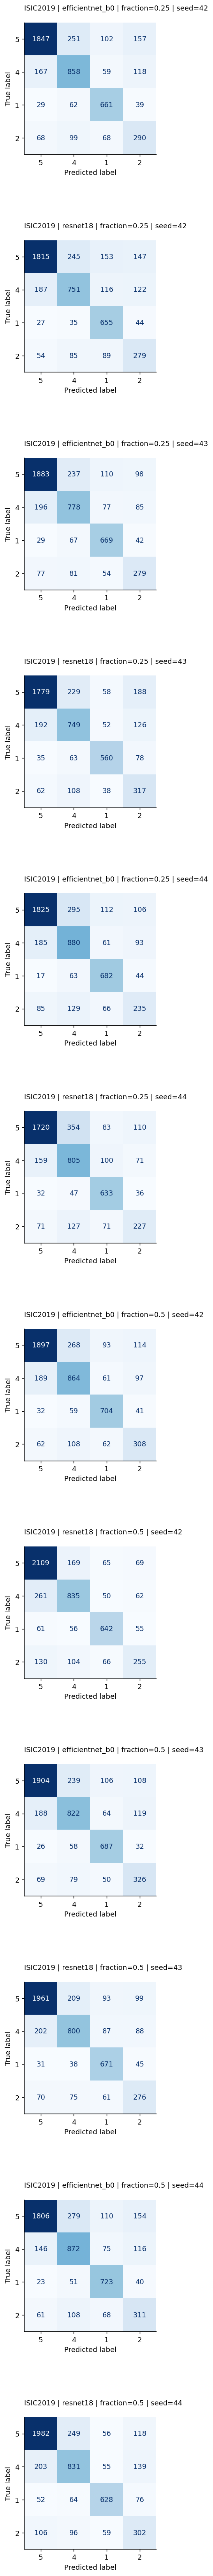

In [ ]:

ISIC_DATASET_NAME = "ISIC2019" if "ISIC2019" in available_datasets else ("isic2019" if "isic2019" in available_datasets else None)

if ISIC_DATASET_NAME is None:
    print("ISIC dataset was not found in final_df.")
else:
    isic_top_classes = get_top_classes(dataset=ISIC_DATASET_NAME, model=None, k=TOP_ISIC_K)
    isic_top_class_table = pd.DataFrame({
        "class_id": isic_top_classes,
        "class_name": [label_to_name(ISIC_DATASET_NAME, x) for x in isic_top_classes]
    })
    display(isic_top_class_table)

    isic_filtered_per_class = classification_table_from_predictions(
        dataset=ISIC_DATASET_NAME,
        model=None,
        classes=isic_top_classes,
    )
    if len(isic_filtered_per_class):
        display(isic_filtered_per_class.sort_values("support", ascending=False))
        isic_filtered_per_class.to_csv(TABLE_DIR / "isic_top4_per_class_table.csv", index=False)

    isic_filtered_runs = plot_filtered_confusions(
        dataset=ISIC_DATASET_NAME,
        model=None,
        classes=isic_top_classes,
        max_runs=12,
    )
    if isinstance(isic_filtered_runs, pd.DataFrame) and len(isic_filtered_runs):
        isic_filtered_runs.to_csv(TABLE_DIR / "isic_top4_confusion_runs.csv", index=False)


## 18. Top 3 classes for Messidor2

,class_id,class_name
0,0,0
1,2,2
2,1,1


,dataset,model,class_id,class_name,precision,recall,f1_score,support
0,Messidor2,None,0,0,0.663441,0.623232,0.642708,990.0
1,Messidor2,None,2,2,0.596234,0.468750,0.524862,608.0
2,Messidor2,None,1,1,0.301887,0.363636,0.329897,440.0


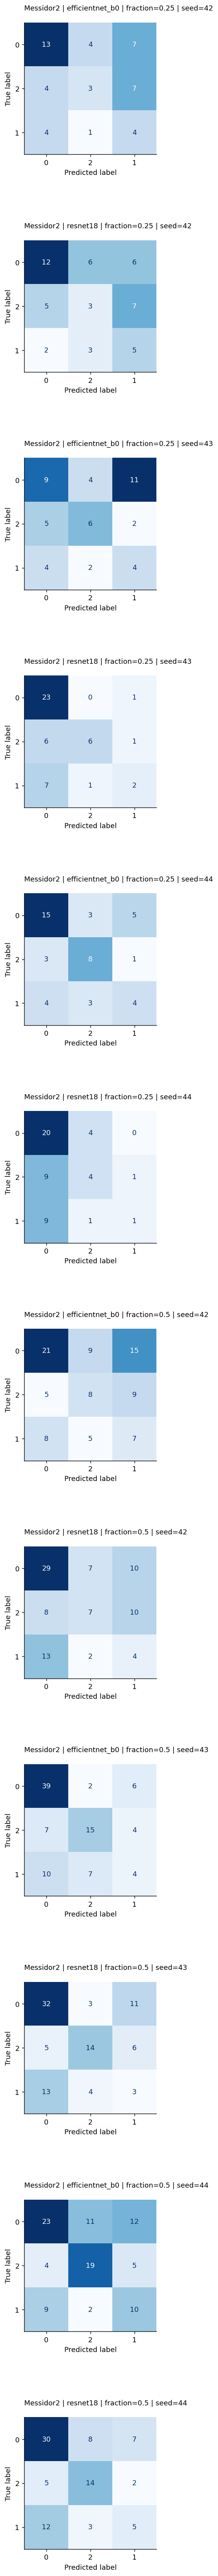

In [ ]:
if MESSIDOR_DATASET_NAME is None:
    print("Messidor2 dataset was not found in final_df.")
else:
    messidor_top_classes = get_top_classes(dataset=MESSIDOR_DATASET_NAME, model=None, k=TOP_MESSIDOR_K)
    messidor_top_class_table = pd.DataFrame({
        "class_id": messidor_top_classes,
        "class_name": [label_to_name(MESSIDOR_DATASET_NAME, x) for x in messidor_top_classes]
    })
    display(messidor_top_class_table)

    messidor_filtered_per_class = classification_table_from_predictions(
        dataset=MESSIDOR_DATASET_NAME,
        model=None,
        classes=messidor_top_classes,
    )
    if len(messidor_filtered_per_class):
        display(messidor_filtered_per_class.sort_values("support", ascending=False))
        messidor_filtered_per_class.to_csv(
            TABLE_DIR / "messidor2_top3_per_class_table.csv",
            index=False,
        )

    messidor_filtered_runs = plot_filtered_confusions(
        dataset=MESSIDOR_DATASET_NAME,
        model=None,
        classes=messidor_top_classes,
        max_runs=12,
    )
    if isinstance(messidor_filtered_runs, pd.DataFrame) and len(messidor_filtered_runs):
        messidor_filtered_runs.to_csv(
            TABLE_DIR / "messidor2_top3_confusion_runs.csv",
            index=False,
        )

## 19. Top 3 classes for chosen dataset/model

,class_id,class_name
0,0,0
1,2,2
2,1,1


,dataset,model,class_id,class_name,precision,recall,f1_score,support
0,Messidor2,resnet18,0,0,0.652610,0.656566,0.654582,495.0
1,Messidor2,resnet18,2,2,0.585903,0.437500,0.500942,304.0
2,Messidor2,resnet18,1,1,0.292887,0.318182,0.305011,220.0


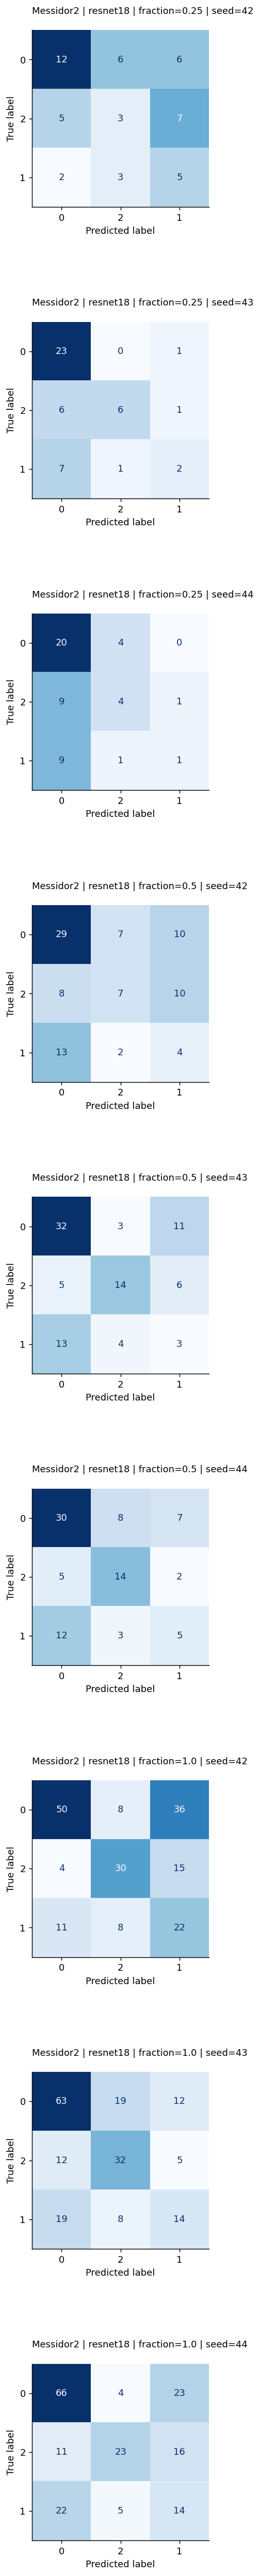

In [ ]:
if CHOSEN_DATASET is None or CHOSEN_MODEL is None:
    print("Set CHOSEN_DATASET and CHOSEN_MODEL in the settings cell above.")
else:
    chosen_top_classes = get_top_classes(dataset=CHOSEN_DATASET, model=CHOSEN_MODEL, k=TOP_CHOSEN_K)
    chosen_top_class_table = pd.DataFrame({
        "class_id": chosen_top_classes,
        "class_name": [label_to_name(CHOSEN_DATASET, x) for x in chosen_top_classes]
    })
    display(chosen_top_class_table)

    chosen_filtered_per_class = classification_table_from_predictions(
        dataset=CHOSEN_DATASET,
        model=CHOSEN_MODEL,
        classes=chosen_top_classes,
    )
    if len(chosen_filtered_per_class):
        display(chosen_filtered_per_class.sort_values("support", ascending=False))
        chosen_filtered_per_class.to_csv(
            TABLE_DIR / f"{CHOSEN_DATASET}_{CHOSEN_MODEL}_top3_per_class_table.csv",
            index=False,
        )

    chosen_filtered_runs = plot_filtered_confusions(
        dataset=CHOSEN_DATASET,
        model=CHOSEN_MODEL,
        classes=chosen_top_classes,
        max_runs=12,
    )
    if isinstance(chosen_filtered_runs, pd.DataFrame) and len(chosen_filtered_runs):
        chosen_filtered_runs.to_csv(
            TABLE_DIR / f"{CHOSEN_DATASET}_{CHOSEN_MODEL}_top3_confusion_runs.csv",
            index=False,
        )

In [ ]:
# ========= FINAL COPYABLE SUMMARY CELL =========
# Change this per notebook:
NOTEBOOK_LABEL = "CNN_Comparison_Analysis_V5"
# NOTEBOOK_LABEL = "ViT_Comparison_Analysis_V4"
# NOTEBOOK_LABEL = "Hybrid_Comparison_Analysis_V1"

from pathlib import Path
from IPython.display import display
import pandas as pd
import numpy as np
import io
import contextlib

def _print_section(title):
    print("\n" + "=" * 100)
    print(title)
    print("=" * 100)

def _safe_exists(name):
    return name in globals() and globals()[name] is not None

def _as_df(obj):
    return isinstance(obj, pd.DataFrame)

def _fmt_df_for_print(df, max_rows=200, max_cols=50, index=False):
    if df is None or len(df) == 0:
        return "[empty]"
    with pd.option_context(
        "display.max_rows", max_rows,
        "display.max_columns", max_cols,
        "display.width", 200,
        "display.max_colwidth", 120,
        "display.float_format", lambda x: f"{x:.4f}" if isinstance(x, (float, np.floating)) else str(x),
    ):
        return df.to_string(index=index)

def _collect_plot_names():
    plot_names = []

    # 1) Best source: files actually saved through save_current_fig into FIG_DIR
    if _safe_exists("FIG_DIR"):
        fig_dir = Path(FIG_DIR)
        if fig_dir.exists():
            pngs = sorted(fig_dir.glob("*.png"))
            pdfs = sorted(fig_dir.glob("*.pdf"))

            if pngs:
                plot_names.extend([p.stem for p in pngs])

            # if only pdfs exist, add those stems too
            if not plot_names and pdfs:
                plot_names.extend([p.stem for p in pdfs])

    # 2) Fallback: reconstruct common names from notebook variables if files are not yet present
    if not plot_names:
        dataset_order = globals().get("DATASET_ORDER", [])
        fraction_order = globals().get("FRACTION_ORDER", [])

        # main metric-vs-fraction plots
        primary_metric = globals().get("PRIMARY_METRIC", None)
        secondary_metrics = globals().get("SECONDARY_METRICS", [])
        metrics = [m for m in [primary_metric] + list(secondary_metrics) if m]

        for ds in dataset_order:
            for metric in metrics:
                plot_names.append(f"{ds}_{metric}_vs_fraction")

        # parameter efficiency
        if _safe_exists("param_eff_df"):
            for ds in dataset_order:
                plot_names.append(f"{ds}_parameter_efficiency_macro_f1_per_mparam")

        # learning curves
        if _safe_exists("history_df"):
            for ds in dataset_order:
                plot_names.append(f"{ds}_learning_curve_val_f1_macro")
                plot_names.append(f"{ds}_learning_curve_val_loss")
                plot_names.append(f"{ds}_learning_curve_train_loss")
                for frac in fraction_order:
                    frac_name = str(frac).replace(".", "p")
                    plot_names.append(f"{ds}_frac_{frac_name}_val_f1_macro")

        # filtered confusion outputs are shown inline, not always saved with a stable filename
        if _safe_exists("best_runs"):
            plot_names.append("best_run_confusion_matrices_inline")

        if _safe_exists("isic_filtered_runs"):
            plot_names.append("isic_topk_filtered_confusions_inline")

        if _safe_exists("chosen_filtered_runs"):
            plot_names.append("chosen_dataset_topk_filtered_confusions_inline")

    plot_names = sorted(set(plot_names))
    return plot_names

def _print_metric_overview():
    if not _safe_exists("final_df") or not _as_df(final_df):
        print("final_df not found.")
        return

    _print_section("1) RAW RUN-LEVEL METRICS (final_df)")

    preferred_cols = [
        "run_id", "dataset", "model", "seed", "data_fraction_used",
        "test_f1_macro", "test_acc", "test_balanced_acc", "test_auroc_ovr", "test_loss",
        "best_epoch", "epochs_trained", "stopped_early", "run_seconds",
        "total_params", "params_millions", "macro_f1_per_mparam", "auroc_per_mparam"
    ]
    existing_cols = [c for c in preferred_cols if c in final_df.columns]
    extra_metric_cols = [
        c for c in final_df.columns
        if c not in existing_cols and (
            "test_" in c or "val_" in c or "train_" in c or
            "epoch" in c or "loss" in c or "acc" in c or "f1" in c or
            "auc" in c or "auroc" in c or "precision" in c or "recall" in c
        )
    ]
    cols_to_show = existing_cols + extra_metric_cols[:20]

    printable_df = final_df[cols_to_show].copy() if cols_to_show else final_df.copy()
    print(_fmt_df_for_print(printable_df, max_rows=min(500, max(50, len(printable_df))), index=False))

    numeric_cols = final_df.select_dtypes(include=[np.number]).columns.tolist()
    if numeric_cols:
        _print_section("2) NUMERIC METRIC SUMMARY (mean/std/min/max)")
        summary = final_df[numeric_cols].agg(["mean", "std", "min", "max"]).T.reset_index()
        summary = summary.rename(columns={"index": "metric"})
        print(_fmt_df_for_print(summary, max_rows=500, index=False))

def _print_saved_tables():
    candidate_tables = [
        "summary_main",
        "compact_main",
        "gain_df",
        "curve_df",
        "pairwise_df",
        "param_eff_df",
        "convergence_summary",
        "convergence_grouped",
        "per_class_summary",
        "best_runs",
        "chapter_table",
        "isic_top_class_table",
        "isic_filtered_per_class",
        "isic_filtered_runs",
        "chosen_top_class_table",
        "chosen_filtered_per_class",
        "chosen_filtered_runs",
    ]

    found_any = False
    for name in candidate_tables:
        if _safe_exists(name) and _as_df(globals()[name]):
            df = globals()[name]
            found_any = True
            _print_section(f"TABLE: {name}  |  shape={df.shape}")
            print(_fmt_df_for_print(df, max_rows=min(300, max(30, len(df))), index=False))

    if not found_any:
        _print_section("TABLES")
        print("No recognised summary tables were found in globals().")

def _build_full_report():
    buf = io.StringIO()
    with contextlib.redirect_stdout(buf):
        print("#" * 100)
        print(f"NOTEBOOK SUMMARY REPORT: {NOTEBOOK_LABEL}")
        print("#" * 100)

        _print_section("0) AVAILABLE INLINE / SAVED PLOTS")
        plots = _collect_plot_names()
        if plots:
            for i, p in enumerate(plots, 1):
                print(f"{i:>3}. {p}")
        else:
            print("No plots detected.")

        _print_metric_overview()
        _print_saved_tables()

    return buf.getvalue()

# Build and print one big copyable report
REPORT_TEXT = _build_full_report()
print(REPORT_TEXT)

# Save to txt so you also have a file copy
if _safe_exists("TABLE_DIR"):
    out_path = Path(TABLE_DIR) / f"{NOTEBOOK_LABEL}_full_summary_report.txt"
else:
    out_path = Path.cwd() / f"{NOTEBOOK_LABEL}_full_summary_report.txt"

out_path.write_text(REPORT_TEXT, encoding="utf-8")
print(f"\nSaved full report to: {out_path}")
# ========= END CELL =========

####################################################################################################
NOTEBOOK SUMMARY REPORT: CNN_Comparison_Analysis_V5
####################################################################################################

0) AVAILABLE INLINE / SAVED PLOTS
  1. ISIC2019_frac_0p25_val_f1_macro
  2. ISIC2019_frac_0p5_val_f1_macro
  3. ISIC2019_frac_1p0_val_f1_macro
  4. ISIC2019_learning_curve_train_loss
  5. ISIC2019_learning_curve_val_f1_macro
  6. ISIC2019_learning_curve_val_loss
  7. ISIC2019_parameter_efficiency_macro_f1_per_mparam
  8. ISIC2019_sample_efficiency_auroc
  9. ISIC2019_sample_efficiency_macro_f1
 10. Messidor2_frac_0p25_val_f1_macro
 11. Messidor2_frac_0p5_val_f1_macro
 12. Messidor2_frac_1p0_val_f1_macro
 13. Messidor2_learning_curve_train_loss
 14. Messidor2_learning_curve_val_f1_macro
 15. Messidor2_learning_curve_val_loss
 16. Messidor2_parameter_efficiency_macro_f1_per_mparam
 17. Messidor2_sample_efficiency_auroc
 18. Messidor2_sam